This code generates the combined csv that are produced by the pruning and benchmarking scripts.

In [2]:
import pandas as pd
import os

# Define the base directory where your Vision folder is located
base_dir = '/Users/arihangupta/Downloads/pruning_project_data/Vision/rerun'

# Define the datasets to process
datasets = ['bloodmnist', 'dermamnist', 'pathmnist']

# Create name mapping dictionary
# Maps benchmarking file names to pruning file names
name_mapping = {
    # Baseline models - position of "baseline" is different
    'vit_base_patch16_224_baseline': 'baseline_vit_base_patch16_224',
    'vit_small_patch16_224_baseline': 'baseline_vit_small_patch16_224',
    'vit_tiny_patch16_224_baseline': 'baseline_vit_tiny_patch16_224',
    
    # KD models - exact match (no mapping needed, but included for clarity)
    'kd_vit_base_patch16_224_to_vit_small_patch16_224': 'kd_vit_base_patch16_224_to_vit_small_patch16_224',
    'kd_vit_base_patch16_224_to_vit_tiny_patch16_224': 'kd_vit_base_patch16_224_to_vit_tiny_patch16_224',
    'kd_vit_small_patch16_224_to_vit_tiny_patch16_224': 'kd_vit_small_patch16_224_to_vit_tiny_patch16_224',
    
    # Quantization models - exact match (no mapping needed, but included for clarity)
    'quantization_vit_base_patch16_224': 'quantization_vit_base_patch16_224',
    'quantization_vit_small_patch16_224': 'quantization_vit_small_patch16_224',
    'quantization_vit_tiny_patch16_224': 'quantization_vit_tiny_patch16_224',

    # Structured pruning models - exact match (no mapping needed, but included for clarity)
    'oneshot_vit_base_patch16_224': 'oneshot_vit_base_patch16_224',
    'oneshot_vit_small_patch16_224': 'oneshot_vit_small_patch16_224',
    'oneshot_vit_tiny_patch16_224': 'oneshot_vit_tiny_patch16_224',
}

for dataset in datasets:
    print(f"\nProcessing {dataset}...")
    
    # Define file paths
    benchmarking_file = os.path.join(base_dir, f'benchmarking_results/{dataset}_results.csv')
    pruning_file = os.path.join(base_dir, f'pruned_models/{dataset}/{dataset}_pruning_results.csv')
    output_file = os.path.join(base_dir, f'{dataset}_combined_results.csv')
    
    # Check if files exist
    if not os.path.exists(benchmarking_file):
        print(f"  Warning: {benchmarking_file} not found, skipping...")
        continue
    if not os.path.exists(pruning_file):
        print(f"  Warning: {pruning_file} not found, skipping...")
        continue
    
    # Read the CSV files
    df_benchmarking = pd.read_csv(benchmarking_file)
    df_pruning = pd.read_csv(pruning_file)
    
    # Remove any unnamed columns
    df_benchmarking = df_benchmarking.loc[:, ~df_benchmarking.columns.str.contains('^Unnamed')]
    df_pruning = df_pruning.loc[:, ~df_pruning.columns.str.contains('^Unnamed')]
    
    print(f"  Benchmarking file shape: {df_benchmarking.shape}")
    print(f"  Pruning file shape: {df_pruning.shape}")
    
    # Create a mapped column in the benchmarking dataframe
    df_benchmarking['mapped_model_name'] = df_benchmarking['model_name'].map(name_mapping)
    
    # Check if any models didn't get mapped
    unmapped = df_benchmarking[df_benchmarking['mapped_model_name'].isna()]['model_name'].unique()
    if len(unmapped) > 0:
        print(f"  WARNING: Some models were not mapped: {unmapped}")
    
    # Perform inner join on mapped_model_name (from benchmarking) and Variant (from pruning)
    df_combined = pd.merge(
        df_benchmarking, 
        df_pruning, 
        left_on='mapped_model_name', 
        right_on='Variant', 
        how='inner'
    )
    
    # Drop the temporary mapped_model_name column
    df_combined = df_combined.drop(columns=['mapped_model_name'])
    
    print(f"  Combined file shape: {df_combined.shape}")
    print(f"  Matched {len(df_combined)} rows")
    
    # Save the combined file
    df_combined.to_csv(output_file, index=False)
    print(f"  Saved to: {output_file}")

print("\nAll datasets processed!")


Processing bloodmnist...
  Benchmarking file shape: (126, 33)
  Pruning file shape: (12, 56)
  Combined file shape: (126, 89)
  Matched 126 rows
  Saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/bloodmnist_combined_results.csv

Processing dermamnist...
  Benchmarking file shape: (126, 33)
  Pruning file shape: (12, 56)
  Combined file shape: (126, 89)
  Matched 126 rows
  Saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/dermamnist_combined_results.csv

Processing pathmnist...
  Benchmarking file shape: (126, 33)
  Pruning file shape: (12, 56)
  Combined file shape: (126, 89)
  Matched 126 rows
  Saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/pathmnist_combined_results.csv

All datasets processed!


This code works to average all of the results (now in one file per dataset) and also store the the SD. This merged result is then used for visualization.

In [3]:
import pandas as pd
import os
import numpy as np
import re

# ----------------------------------------------------------------------
# CONFIGURATION - Change these values as needed
# ----------------------------------------------------------------------
base_dir = '/Users/arihangupta/Downloads/pruning_project_data/Vision/rerun'
output_dir = os.path.join(base_dir, 'merged_results')
os.makedirs(output_dir, exist_ok=True)

datasets = ['bloodmnist', 'dermamnist', 'pathmnist']

# Updated columns_to_average with correct column names for rerun data
columns_to_average = [
    'Acc', 'AUC', 'Precision', 'Recall',
    'InferenceTime_per_batch_s', 'PeakRAM_MB',
    'TrainingEnergy_kWh', 'TrainingEmissions_kg',  # Fixed column names
    'images_processed', 'elapsed_s', 'throughput_imgs_per_s',
    'auc', 'median_batch_ms', 'p50_ms', 'p90_ms',
    'peak_gpu_mem_MB', 'avg_power_W',
    'energy_kWh_total', 'energy_kWh_per_batch', 'energy_kWh_per_image',
    'emissions_kg_total', 'cpu_power_w', 'gpu_power_w', 'ram_power_w',
    # Additional columns from rerun data
    'FLOPs_per_image', 'FLOPs_M_per_image'
]

grouping_columns = [
    'model_name', 'pruning_method', 'sparsity',
    'stored_precision', 'batch_size', 'runtime_precision'
]

# ----------------------------------------------------------------------
# PROCESS EACH DATASET
# ----------------------------------------------------------------------
for dataset in datasets:
    print(f"\nProcessing {dataset}...")

    input_file = os.path.join(base_dir, f'{dataset}_combined_results.csv')
    if not os.path.exists(input_file):
        print(f"  Warning: {input_file} not found, skipping...")
        continue

    df = pd.read_csv(input_file)
    original_count = len(df)
    print(f"  Original shape: {df.shape}")
    print(f"  Reps found: {sorted(df['rep'].unique())}")

    # --------------------------------------------------------------
    # 1. Verify model size column
    # --------------------------------------------------------------
    if 'ModelSizeMB' not in df.columns:
        print("  Error: 'ModelSizeMB' column missing!")
        continue

    # --------------------------------------------------------------
    # 2. DELETE: baseline pruning_method + mismatched precision
    # --------------------------------------------------------------
    delete_mask = (
        (df['pruning_method'] == 'baseline') &
        (df['stored_precision'] != df['runtime_precision'])
    )
    deleted_count = delete_mask.sum()
    df = df[~delete_mask].copy()
    print(f"  Deleted {deleted_count} baseline rows with mismatched precision")

    # --------------------------------------------------------------
    # 3. Build lookup: quantized model → size (MB)
    # --------------------------------------------------------------
    quant_names = [
        'quantization_vit_base_patch16_224',
        'quantization_vit_small_patch16_224',
        'quantization_vit_tiny_patch16_224'
    ]

    quant_model_sizes = {}
    for qname in quant_names:
        mask = df['model_name'].str.contains(qname, na=False)
        if mask.any():
            size = df.loc[mask, 'ModelSizeMB'].iloc[0]
            quant_model_sizes[qname] = size
            print(f"    Quantized size: {qname} = {size:.2f} MB")
        else:
            print(f"    Warning: No rows for quantized model '{qname}'")

    # --------------------------------------------------------------
    # 4. Add precision_status
    # --------------------------------------------------------------
    def classify_precision(row):
        if any(q in row['model_name'] for q in quant_names):
            return "quantized"
        return "baseline" if row['stored_precision'] == row['runtime_precision'] else "quantized"

    df['precision_status'] = df.apply(classify_precision, axis=1)

    # --------------------------------------------------------------
    # 5. FIX ModelSizeMB for quantized rows (EXCLUDING structured pruning models)
    # Structured pruning models keep their actual pruned model size
    # --------------------------------------------------------------
    def fix_model_size(row):
        # Keep original size for baseline precision
        if row['precision_status'] == 'baseline':
            return row['ModelSizeMB']
        
        model_name = row['model_name']
        pruning_method = row['pruning_method']
        runtime_precision = row['runtime_precision']
        
        # For structured pruning models: apply quantization factor if running with amp
        if pruning_method == 'oneshot':
            if runtime_precision == 'amp':
                # Quantized runtime uses ~half the model size
                return row['ModelSizeMB'] / 2.0
            else:
                return row['ModelSizeMB']

        # 1. KD-style: kd_*_to_vit_*_patch16_224
        kd_match = re.search(r'kd_.*_to_(vit_(?:base|small|tiny)_patch16_224)', model_name)
        if kd_match:
            target = kd_match.group(1)
            quant_key = f"quantization_{target}"
            if quant_key in quant_model_sizes:
                new_sz = quant_model_sizes[quant_key]
                return new_sz

        # 2. Any other quantized run (e.g. baseline model with amp/int8)
        base_match = re.search(r'(vit_(?:base|small|tiny)_patch16_224)', model_name)
        if base_match:
            base_part = base_match.group(1)
            quant_key = f"quantization_{base_part}"
            if quant_key in quant_model_sizes:
                new_sz = quant_model_sizes[quant_key]
                return new_sz

        return row['ModelSizeMB']

    df['ModelSizeMB'] = df.apply(fix_model_size, axis=1)

    # --------------------------------------------------------------
    # 6. Group-by and aggregate - FIXED AVERAGING LOGIC
    # --------------------------------------------------------------
    full_group_cols = grouping_columns + ['precision_status']

    agg_dict = {}
    for col in columns_to_average:
        if col in df.columns:
            agg_dict[col] = ['mean', 'std']

    agg_dict['ModelSizeMB'] = ['mean', 'std']

    # For non-averaged columns, take the first value (they should be same across reps)
    for col in df.columns:
        if col not in full_group_cols and col not in columns_to_average and col not in ['run_id', 'rep', 'ModelSizeMB']:
            agg_dict[col] = 'first'

    df_averaged = df.groupby(full_group_cols, as_index=False).agg(agg_dict)

    # --------------------------------------------------------------
    # 7. Flatten multi-level columns
    # --------------------------------------------------------------
    new_columns = []
    for col in df_averaged.columns:
        if isinstance(col, tuple):
            if col[1] == 'mean':
                new_columns.append(col[0])
            elif col[1] == 'std':
                new_columns.append(f"{col[0]}_sd")
            else:
                new_columns.append(col[0])
        else:
            new_columns.append(col)

    df_averaged.columns = new_columns

    # --------------------------------------------------------------
    # 8. Re-order: metric then _sd
    # --------------------------------------------------------------
    final_columns = []
    processed = set()
    for col in df_averaged.columns:
        if col not in processed:
            final_columns.append(col)
            processed.add(col)
            sd_col = f"{col}_sd"
            if sd_col in df_averaged.columns and sd_col not in processed:
                final_columns.append(sd_col)
                processed.add(sd_col)

    df_averaged = df_averaged[final_columns]

    print(f"  Final shape after processing: {df_averaged.shape}")
    print(f"  Total rows: {original_count} → {len(df)} kept → {len(df_averaged)} groups")
    
    # Verify averaging worked correctly
    print(f"  Verification - checking throughput averaging:")
    baseline_check = df_averaged[
        (df_averaged['model_name'].str.contains('baseline')) & 
        (df_averaged['batch_size'] == 8)
    ]
    if not baseline_check.empty:
        for _, row in baseline_check.iterrows():
            print(f"    {row['model_name']}, {row['runtime_precision']}: "
                  f"throughput={row['throughput_imgs_per_s']:.2f} ± {row['throughput_imgs_per_s_sd']:.2f}")
    
    # Verify structured pruning model sizes are preserved
    print(f"  Verification - structured pruning model sizes:")
    oneshot_check = df_averaged[df_averaged['pruning_method'] == 'oneshot']
    if not oneshot_check.empty:
        for _, row in oneshot_check.head(4).iterrows():
            print(f"    {row['model_name']}, {row['runtime_precision']}: size={row['ModelSizeMB']:.2f} MB")

    # --------------------------------------------------------------
    # 9. Save
    # --------------------------------------------------------------
    output_file = os.path.join(output_dir, f'{dataset}_averaged_results.csv')
    df_averaged.to_csv(output_file, index=False)
    print(f"  Saved to: {output_file}")

print("\nAll datasets processed!")
print(f"Results saved to: {output_dir}")



Processing bloodmnist...
  Original shape: (126, 89)
  Reps found: [0, 1, 2]
  Deleted 18 baseline rows with mismatched precision
    Quantized size: quantization_vit_base_patch16_224 = 163.72 MB
    Quantized size: quantization_vit_small_patch16_224 = 41.39 MB
    Quantized size: quantization_vit_tiny_patch16_224 = 10.60 MB
  Final shape after processing: (36, 115)
  Total rows: 126 → 108 kept → 36 groups
  Verification - checking throughput averaging:
    vit_base_patch16_224_baseline, fp32: throughput=103.03 ± 0.14
    vit_small_patch16_224_baseline, fp32: throughput=336.22 ± 0.18
    vit_tiny_patch16_224_baseline, fp32: throughput=754.48 ± 3.42
  Verification - structured pruning model sizes:
    oneshot_vit_base_patch16_224, amp: size=41.06 MB
    oneshot_vit_base_patch16_224, fp32: size=82.13 MB
    oneshot_vit_base_patch16_224, amp: size=41.06 MB
    oneshot_vit_base_patch16_224, fp32: size=82.13 MB
  Saved to: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/merg

Vision Transformer Radar chart creation along with LaTeX Table. 


################################################################################
# Processing BLOODMNIST with BATCH_SIZE=32
################################################################################

Processing Dataset: BLOODMNIST (Batch Size: 32)
Loaded CSV with 36 rows
Columns: ['model_name', 'pruning_method', 'sparsity', 'stored_precision', 'batch_size', 'runtime_precision', 'precision_status', 'Acc', 'Acc_sd', 'AUC']...
Filtered to 18 rows with batch_size=32

Data summary after filtering:
  kd_vit_base_patch16_224_to_vit_small_patch16_224: method=kd, precision=amp
  kd_vit_base_patch16_224_to_vit_small_patch16_224: method=kd, precision=fp32
  kd_vit_base_patch16_224_to_vit_tiny_patch16_224: method=kd, precision=amp
  kd_vit_base_patch16_224_to_vit_tiny_patch16_224: method=kd, precision=fp32
  kd_vit_small_patch16_224_to_vit_tiny_patch16_224: method=kd, precision=amp
  kd_vit_small_patch16_224_to_vit_tiny_patch16_224: method=kd, precision=fp32
  oneshot_vit_base_patch16_224: 

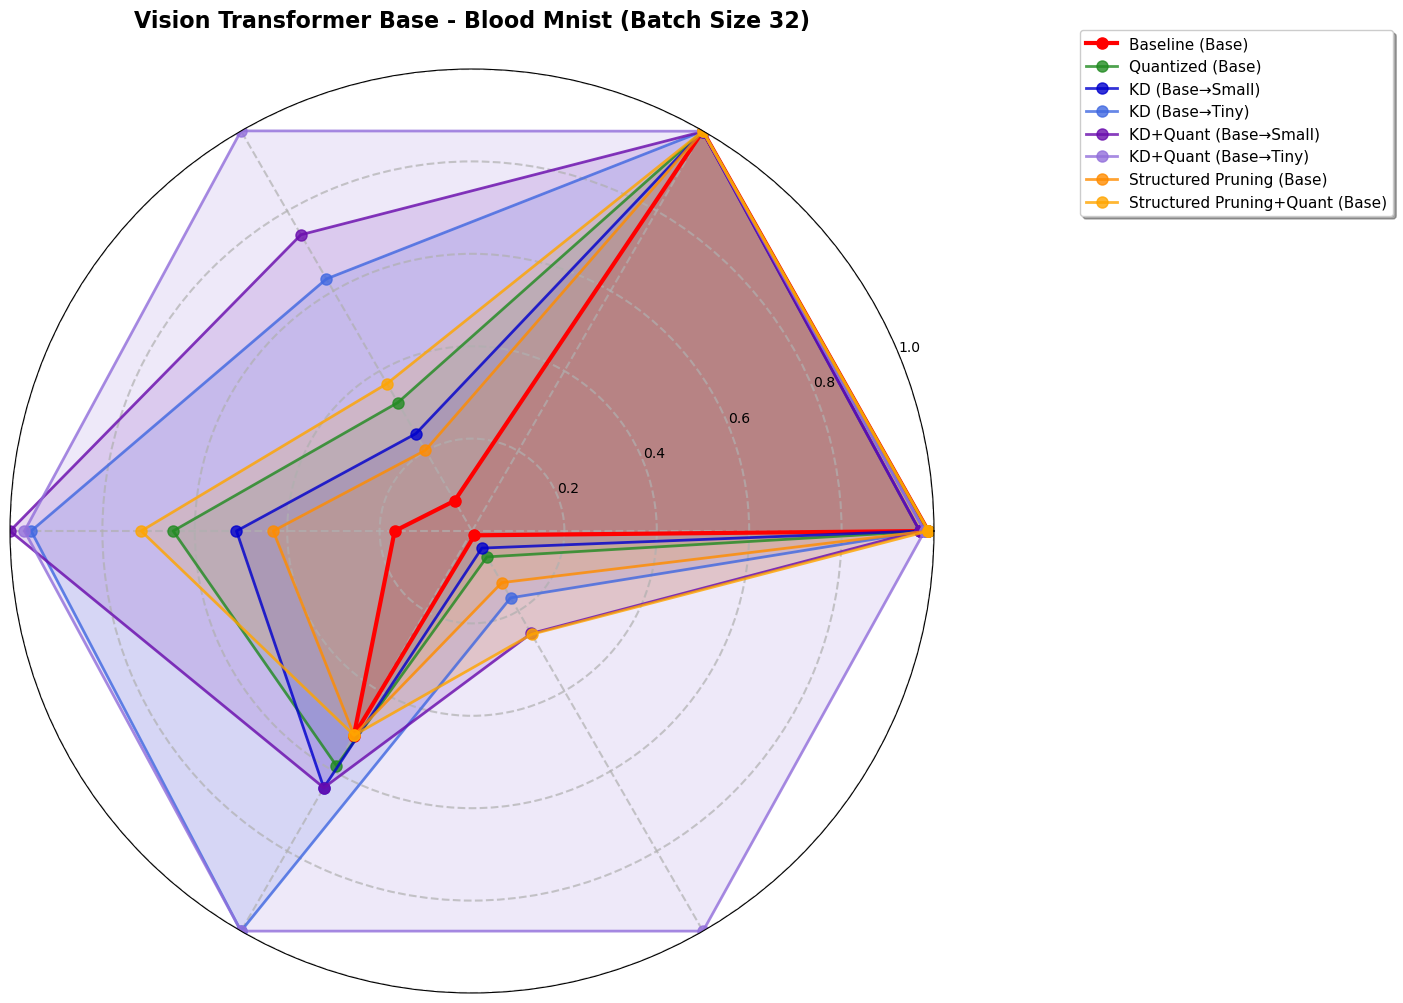


Base Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Base)                0.9877       0.999328     105.98          3.16e-07        2384.2       982.2       
Quantized (Base)               0.9877       0.999269     450.59          8.19e-08        2078.9       163.7       
KD (Base→Small)                0.9690       0.998366     341.42          1.04e-07        1901.3       248.2       
KD (Base→Tiny)                 0.9798       0.999187     884.49          5.55e-08        1219.9       63.5        
KD+Quant (Base→Small)          0.9690       0.998366     1039.47         5.30e-08        1901.3       41.4        
KD+Quant (Base→Tiny)           0.9798       0.999187     1403.80         5.47e-08        1219.9       10.6        
Structured Pruning (Base) 

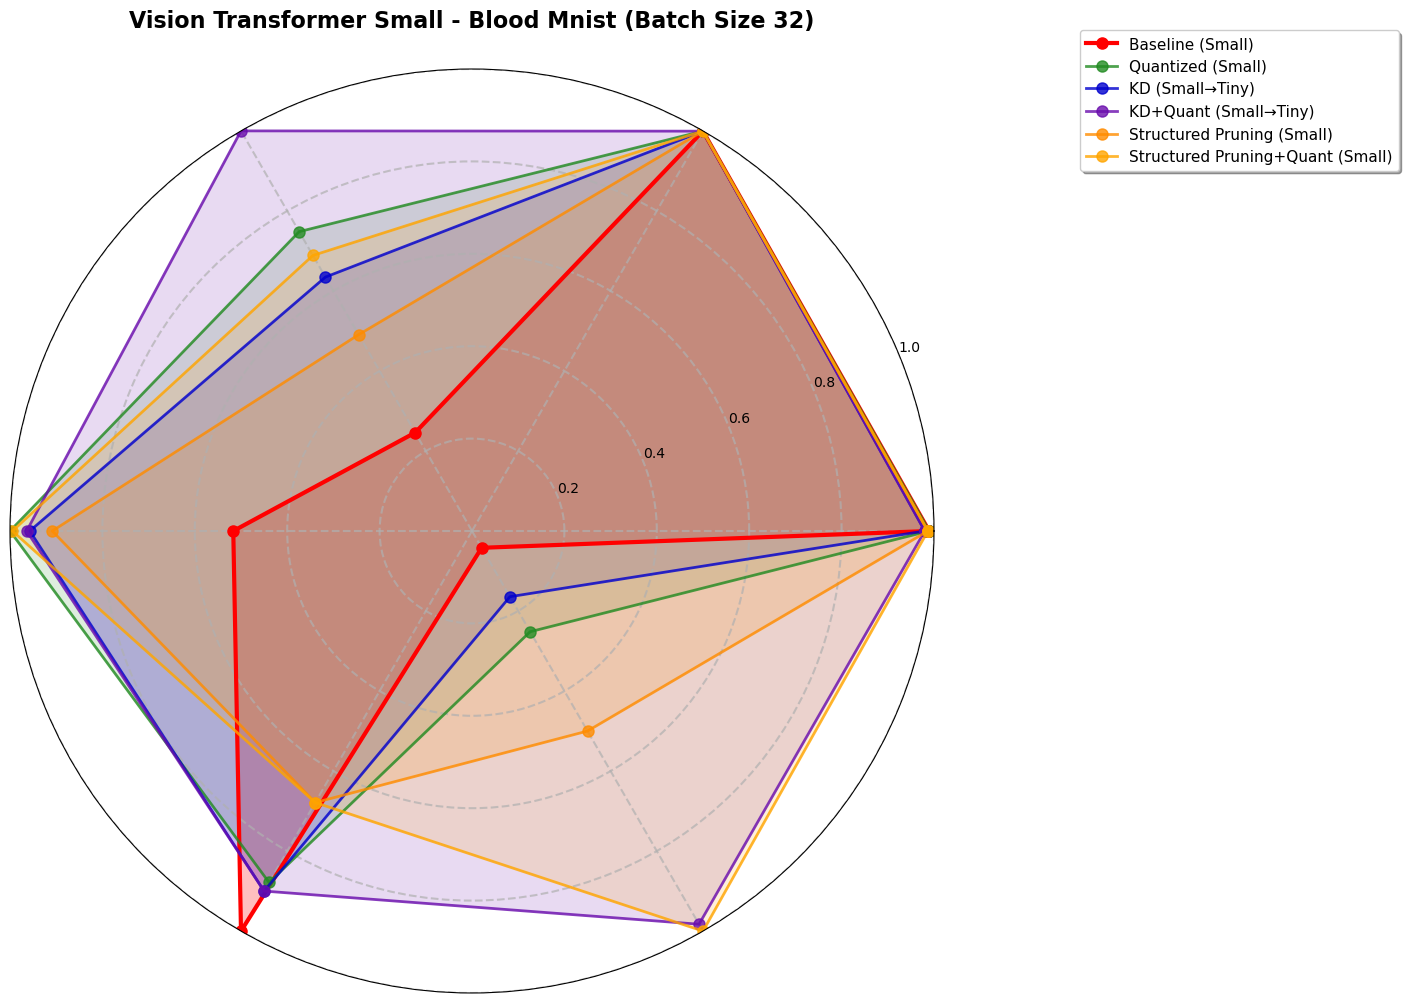


Small Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Small)               0.9895       0.999596     341.08          1.04e-07        881.1        248.2       
Quantized (Small)              0.9895       0.999615     1037.55         5.35e-08        1002.9       41.4        
KD (Small→Tiny)                0.9801       0.999318     880.08          5.59e-08        979.0        63.5        
KD+Quant (Small→Tiny)          0.9801       0.999318     1386.81         5.55e-08        979.0        10.6        
Structured Pruning (Small)     0.9868       0.999425     680.59          5.89e-08        1298.2       20.8        
Structured Pruning+Quant (Small) 0.9868       0.999425     955.09          5.38e-08        1298.2       10.4        

Creating radar chart a

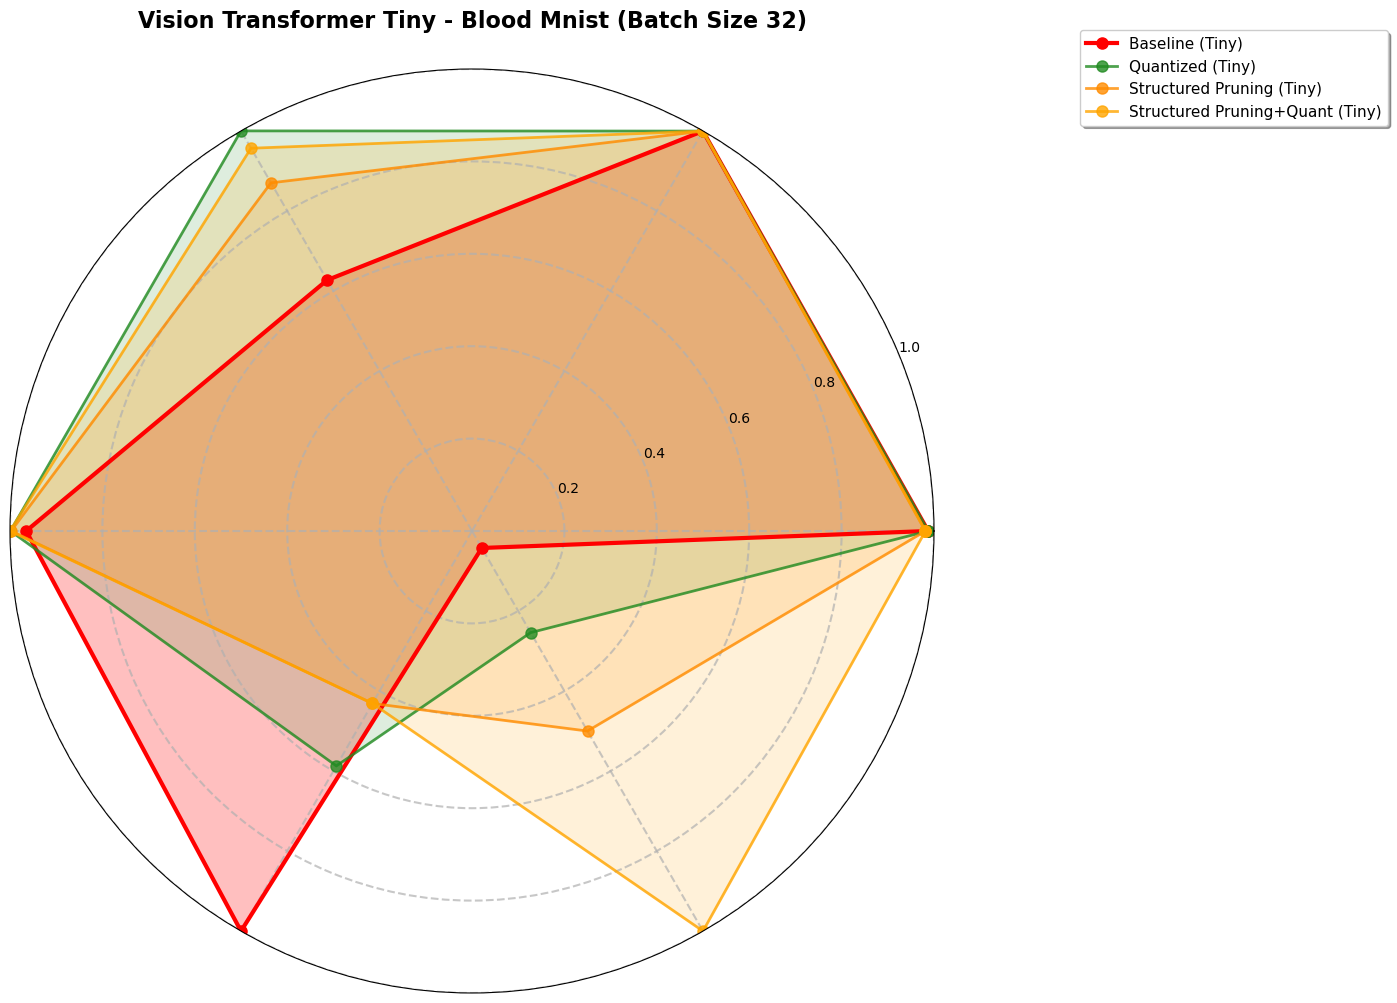


Tiny Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Tiny)                0.9874       0.999537     882.65          5.63e-08        388.5        63.4        
Quantized (Tiny)               0.9874       0.999534     1407.45         5.44e-08        661.6        10.6        
Structured Pruning (Tiny)      0.9816       0.999389     1224.73         5.45e-08        901.2        5.4         
Structured Pruning+Quant (Tiny) 0.9816       0.999389     1346.47         5.44e-08        901.2        2.7         

################################################################################
# Processing DERMAMNIST with BATCH_SIZE=32
################################################################################

Processing Dataset: DERMAMNIST (Batch Size: 32)


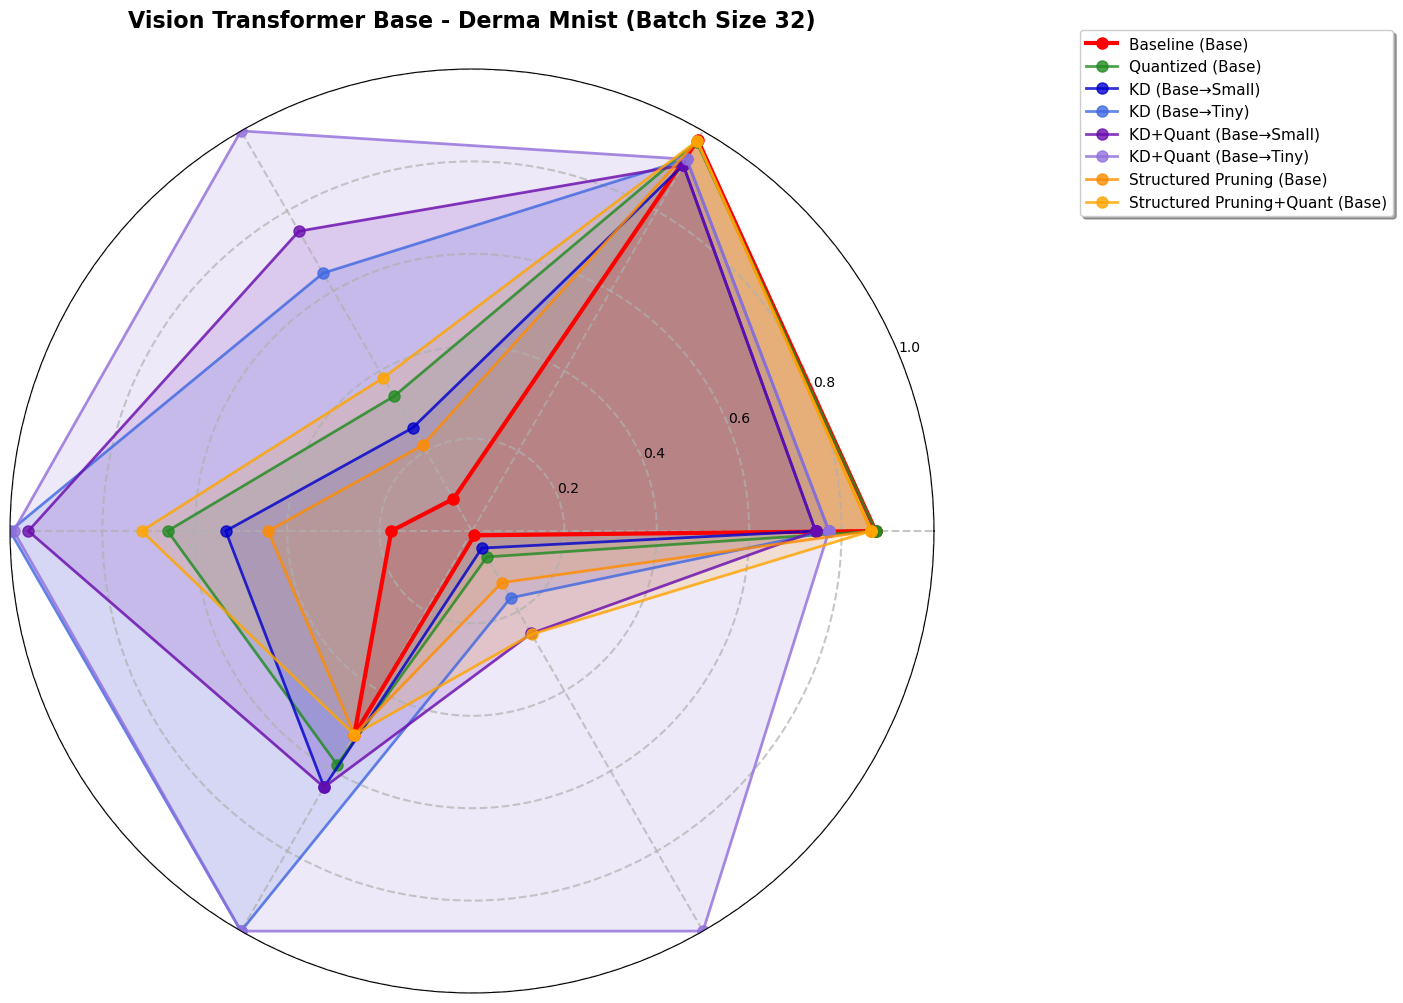


Base Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Base)                0.8738       0.977329     105.47          3.47e-07        2393.8       982.1       
Quantized (Base)               0.8738       0.972625     442.22          9.20e-08        2090.5       163.7       
KD (Base→Small)                0.7436       0.914475     337.91          1.14e-07        1906.1       248.2       
KD (Base→Tiny)                 0.7726       0.929237     845.66          6.06e-08        1220.7       63.4        
KD+Quant (Base→Small)          0.7436       0.914475     983.18          6.31e-08        1906.1       41.4        
KD+Quant (Base→Tiny)           0.7726       0.929237     1312.03         6.11e-08        1220.7       10.6        
Structured Pruning (Base) 

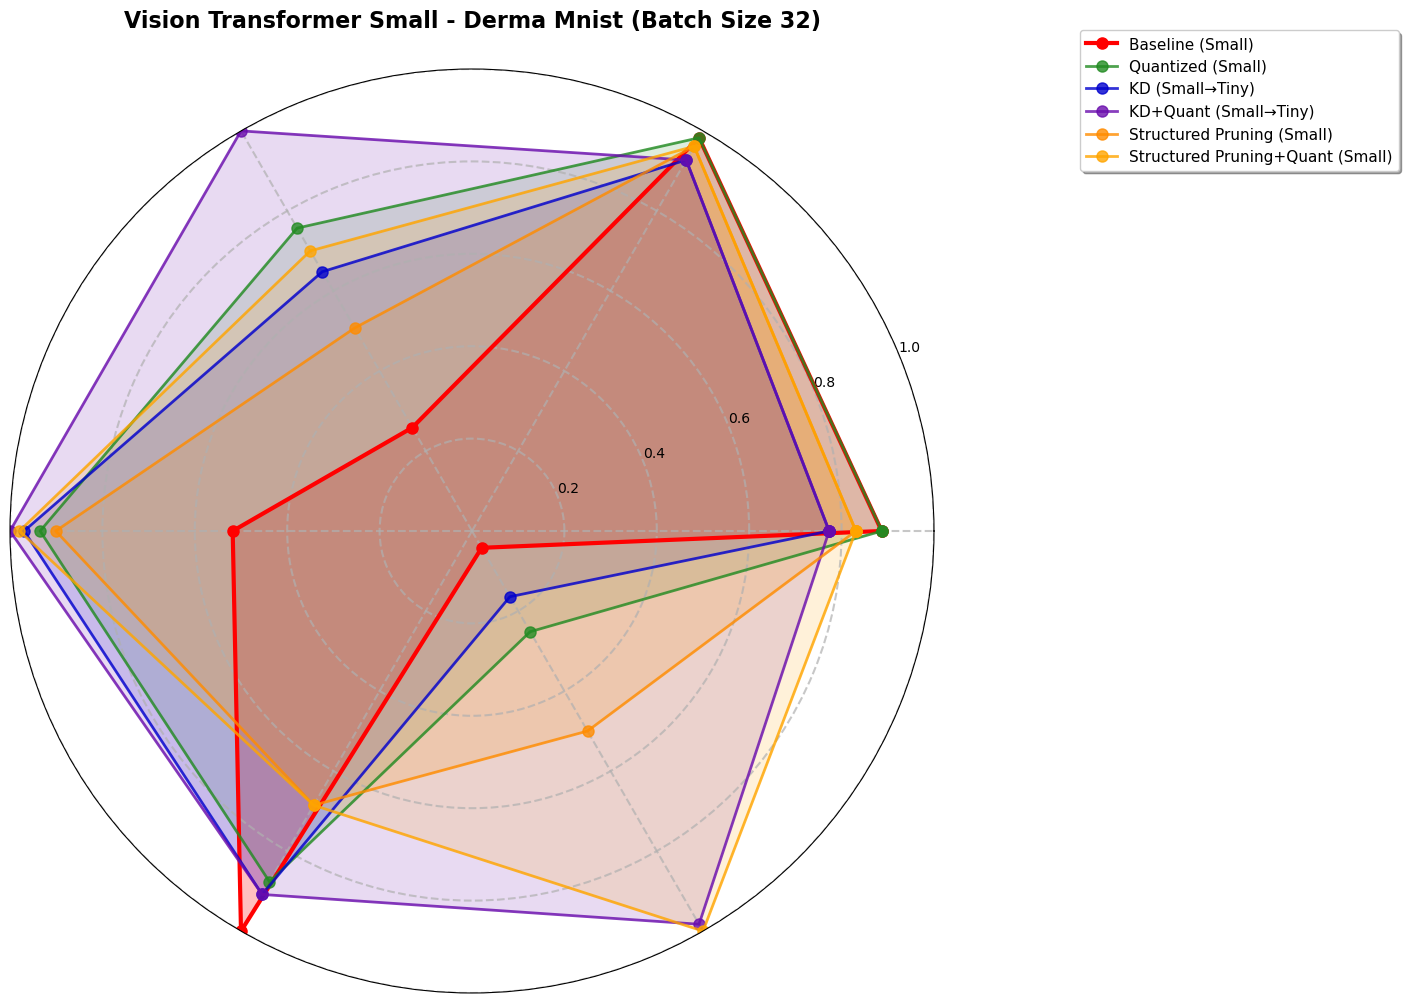


Small Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Small)               0.8868       0.982864     336.10          1.14e-07        890.1        248.2       
Quantized (Small)              0.8873       0.982694     984.42          6.31e-08        1015.4       41.4        
KD (Small→Tiny)                0.7731       0.927214     842.75          6.09e-08        979.9        63.4        
KD+Quant (Small→Tiny)          0.7731       0.927214     1300.46         5.90e-08        979.9        10.6        
Structured Pruning (Small)     0.8309       0.961518     660.02          6.55e-08        1298.7       20.8        
Structured Pruning+Quant (Small) 0.8309       0.961518     910.43          6.03e-08        1298.7       10.4        

Creating radar chart a

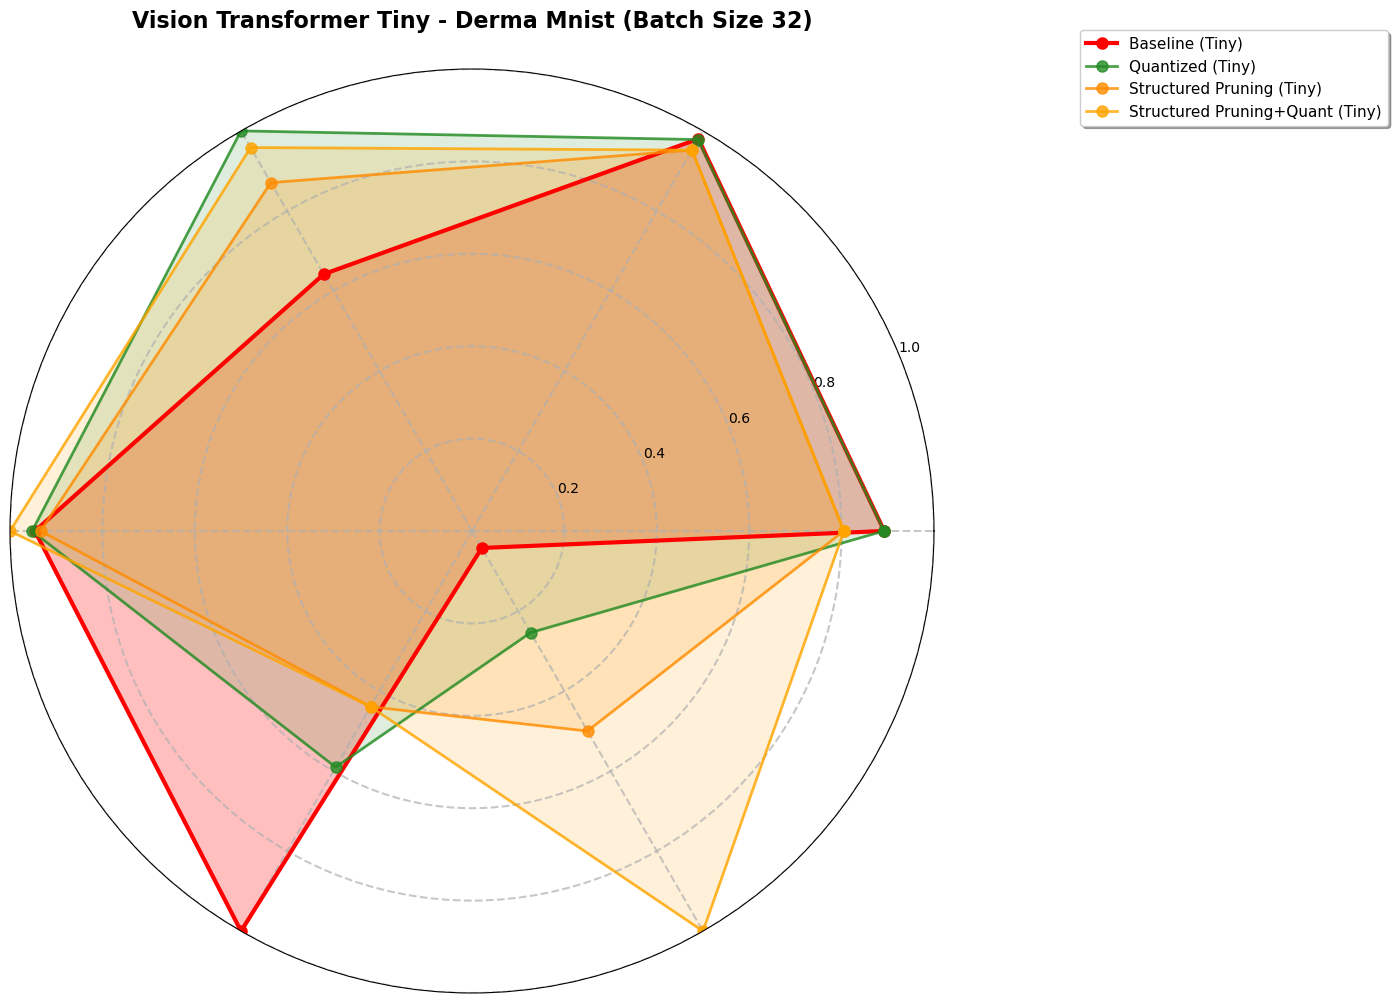


Tiny Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Tiny)                0.8923       0.980073     843.72          6.08e-08        396.6        63.4        
Quantized (Tiny)               0.8918       0.978311     1314.34         6.04e-08        671.9        10.6        
Structured Pruning (Tiny)      0.8050       0.952007     1144.43         6.16e-08        902.9        5.4         
Structured Pruning+Quant (Tiny) 0.8050       0.952007     1259.69         5.75e-08        902.9        2.7         

################################################################################
# Processing PATHMNIST with BATCH_SIZE=32
################################################################################

Processing Dataset: PATHMNIST (Batch Size: 32)
Lo

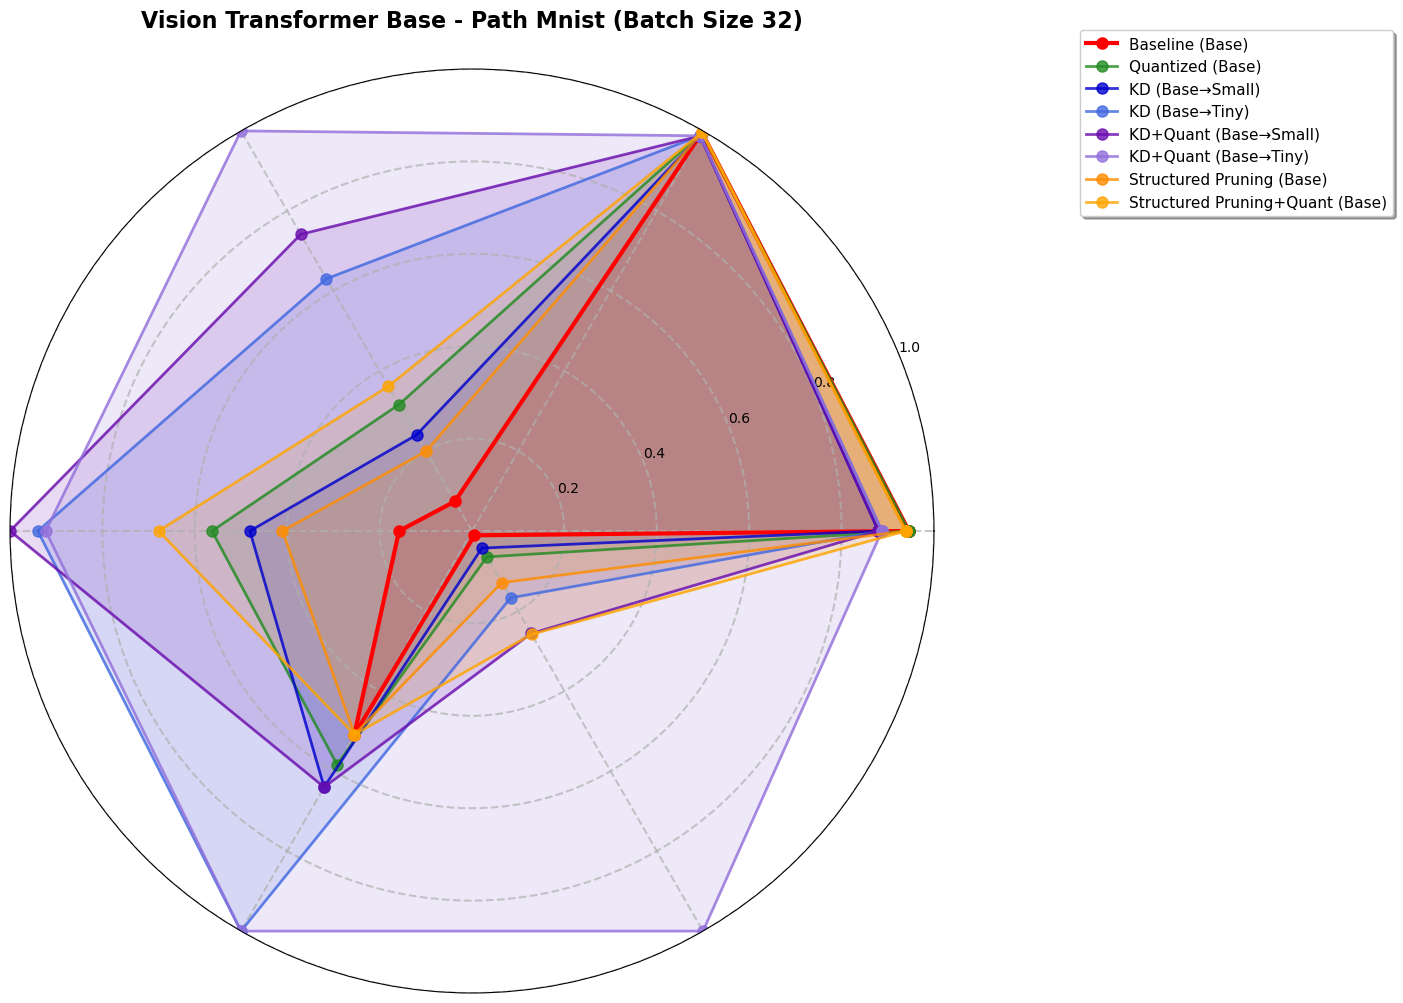


Base Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Base)                0.9457       0.995728     105.69          3.09e-07        2393.8       982.2       
Quantized (Base)               0.9455       0.995473     451.20          8.68e-08        2090.5       163.7       
KD (Base→Small)                0.8798       0.987484     342.86          1.02e-07        1907.0       248.2       
KD (Base→Tiny)                 0.8872       0.987753     899.72          5.20e-08        1220.8       63.5        
KD+Quant (Base→Small)          0.8798       0.987484     1058.32         4.89e-08        1907.0       41.4        
KD+Quant (Base→Tiny)           0.8872       0.987753     1427.33         5.30e-08        1220.8       10.6        
Structured Pruning (Base) 

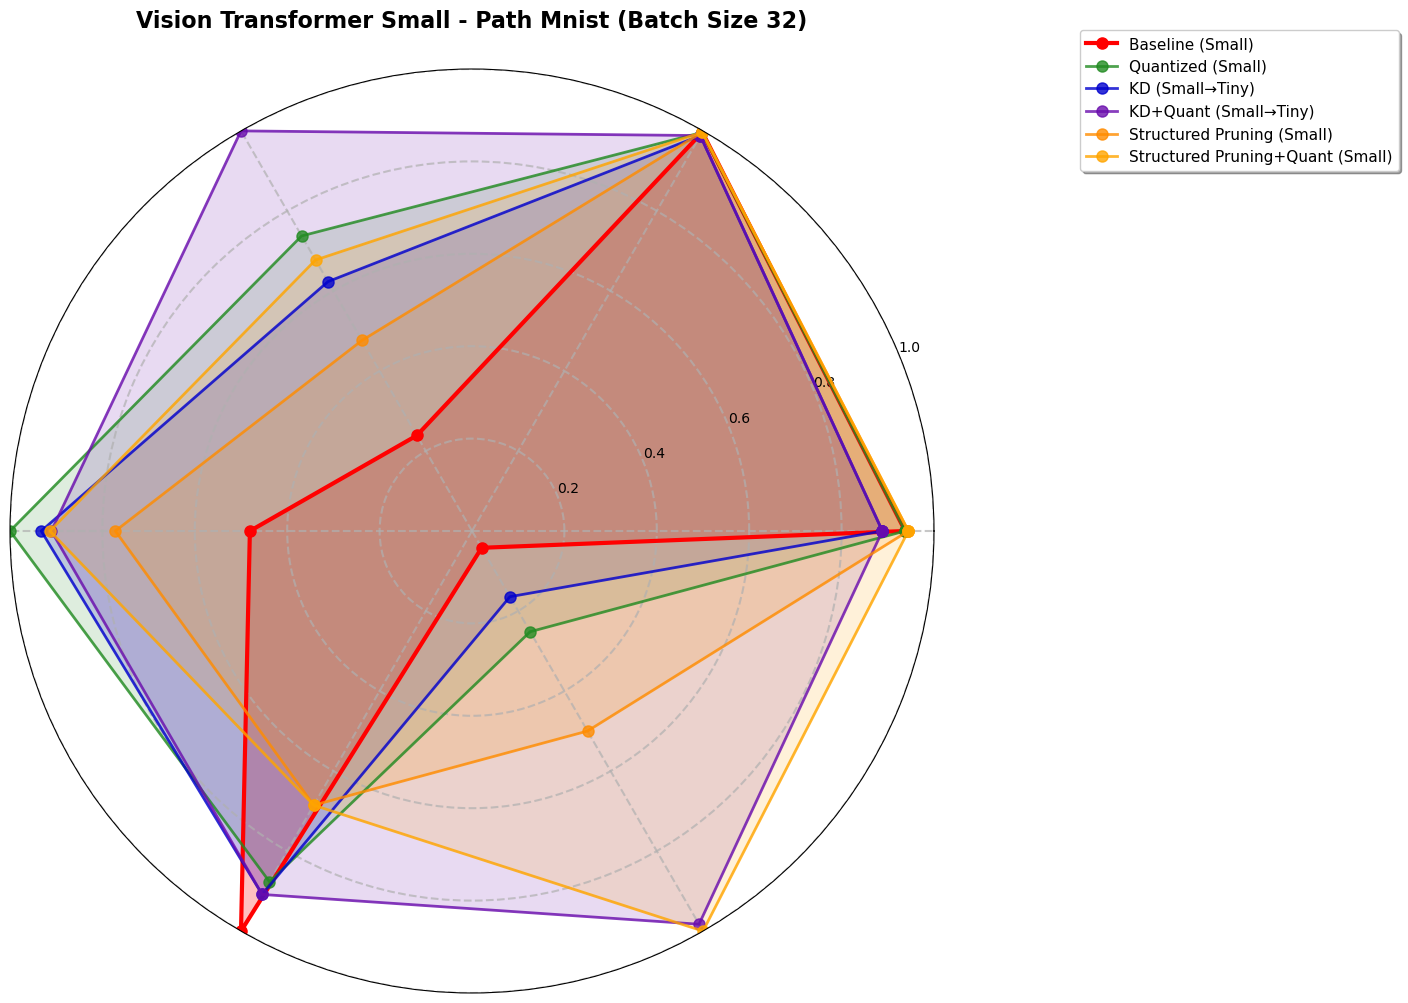


Small Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Small)               0.9375       0.996962     343.06          1.01e-07        890.1        248.2       
Quantized (Small)              0.9375       0.996367     1059.69         4.87e-08        1015.4       41.4        
KD (Small→Tiny)                0.8882       0.988299     895.63          5.22e-08        979.9        63.5        
KD+Quant (Small→Tiny)          0.8882       0.988299     1436.87         5.35e-08        979.9        10.6        
Structured Pruning (Small)     0.9445       0.996667     684.43          6.31e-08        1298.9       20.8        
Structured Pruning+Quant (Small) 0.9445       0.996667     973.21          5.33e-08        1298.9       10.4        

Creating radar chart a

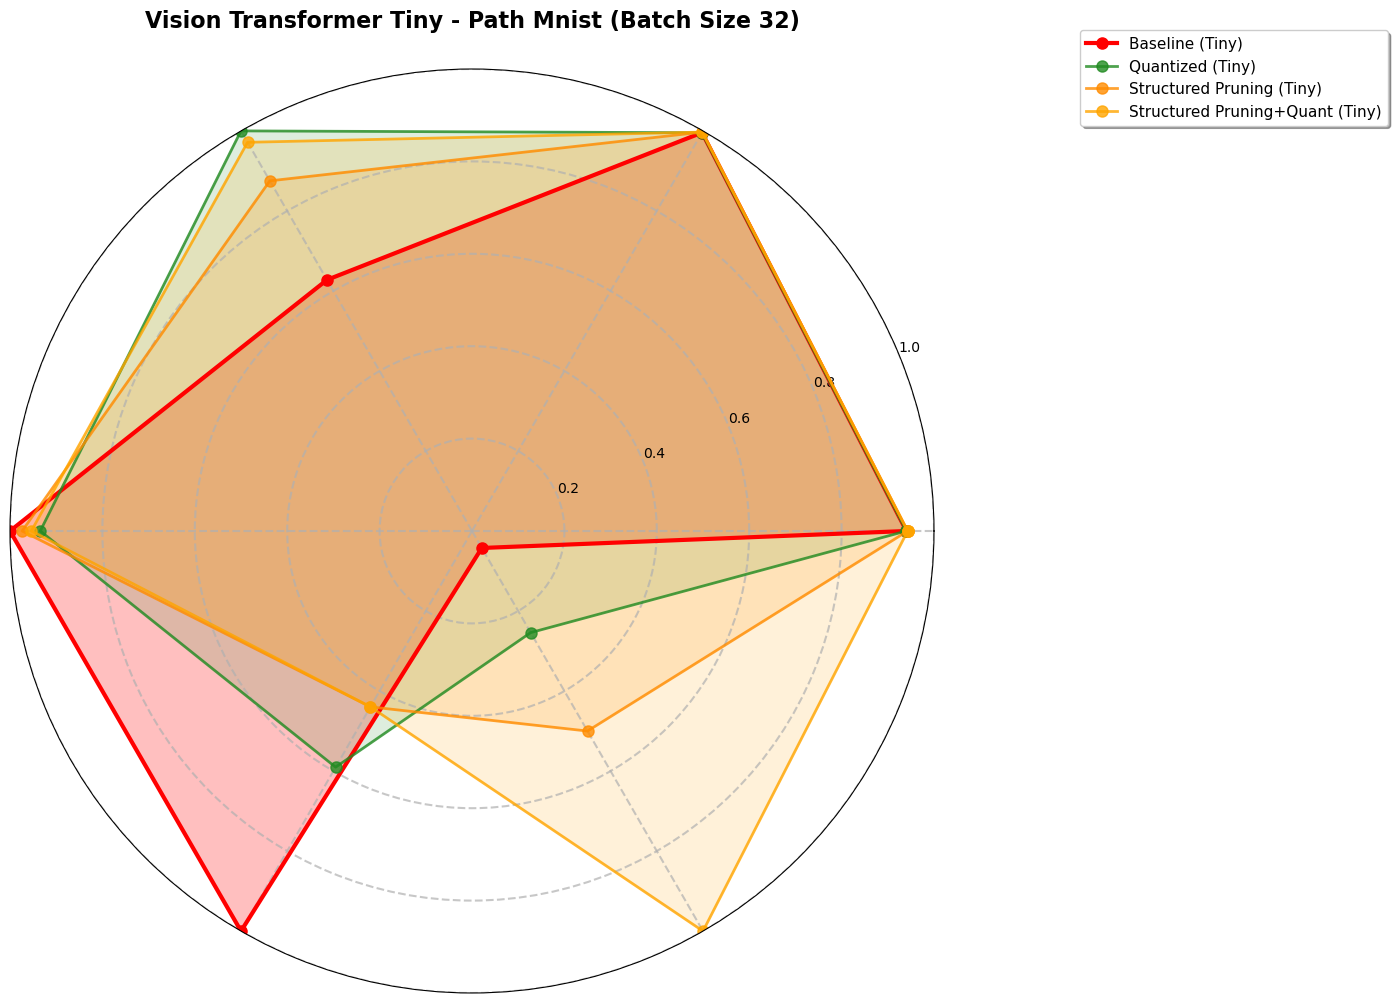


Tiny Model Performance Summary (Batch Size 32)
Model                          Accuracy     AUC          Throughput      Energy/img      RAM (MB)     Size (MB)   
------------------------------------------------------------------------------------------------------------------------
Baseline (Tiny)                0.9403       0.995741     896.32          5.29e-08        396.6        63.4        
Quantized (Tiny)               0.9403       0.995351     1427.93         5.66e-08        671.9        10.6        
Structured Pruning (Tiny)      0.9430       0.997024     1249.63         5.43e-08        902.2        5.4         
Structured Pruning+Quant (Tiny) 0.9430       0.997024     1387.20         5.54e-08        902.2        2.7         

################################################################################
# Processing Complete!
# Output directory: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/Visuals
###########################################################

In [4]:
"""
Vision Transformer Radar Chart Visualization with LaTeX Table Generation

This script creates radar charts for Vision Transformer models (Base, Small, Tiny)
and generates comprehensive LaTeX tables with raw and normalized metrics.

CONFIGURATION:
- Change BATCH_SIZE below to switch between 8 and 32

Usage:
    python vision_radar_modified.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
import os

# ======================================================================
# CONFIGURATION - Change this value to switch between batch sizes
# ======================================================================
BATCH_SIZE = 32  # Options: 8 or 32
# ======================================================================


def create_method_label(row):
    """Create display labels for each method variant."""
    method = row['pruning_method']
    precision = row['runtime_precision']
    variant = row['Variant']
    
    # BASE chart: Shows all optimizations derived from baseline_vit_base_patch16_224
    # SMALL chart: Shows all optimizations derived from baseline_vit_small_patch16_224
    # TINY chart: Shows all optimizations derived from baseline_vit_tiny_patch16_224
    
    if variant == 'baseline_vit_base_patch16_224' and precision == 'fp32':
        return 'Baseline (Base)', 'baseline', 0, 'Base'
    
    elif variant == 'baseline_vit_small_patch16_224' and method == 'baseline' and precision == 'fp32':
        return 'Baseline (Small)', 'baseline', 0, 'Small'
    
    elif variant == 'baseline_vit_tiny_patch16_224' and method == 'baseline' and precision == 'fp32':
        return 'Baseline (Tiny)', 'baseline', 0, 'Tiny'
    
    # Quantized versions - grouped by which baseline was quantized
    elif method == 'quantization' and precision == 'amp':
        if 'vit_base_patch' in variant:
            return 'Quantized (Base)', 'quantized', 1, 'Base'
        elif 'vit_small_patch' in variant:
            return 'Quantized (Small)', 'quantized', 1, 'Small'
        elif 'vit_tiny_patch' in variant:
            return 'Quantized (Tiny)', 'quantized', 1, 'Tiny'
    
    # Structured pruning models
    elif method == 'oneshot':
        if 'vit_base_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Base)', 'oneshot_quant', 6, 'Base'
            else:
                return 'Structured Pruning (Base)', 'oneshot', 5, 'Base'
        elif 'vit_small_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Small)', 'oneshot_quant', 6, 'Small'
            else:
                return 'Structured Pruning (Small)', 'oneshot', 5, 'Small'
        elif 'vit_tiny_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Tiny)', 'oneshot_quant', 6, 'Tiny'
            else:
                return 'Structured Pruning (Tiny)', 'oneshot', 5, 'Tiny'
    
    # Knowledge Distillation - grouped by TEACHER (source) model
    elif method == 'kd' and precision == 'fp32':
        if 'base' in variant and 'small' in variant:
            return 'KD (Base→Small)', 'kd', 2, 'Base'
        elif 'base' in variant and 'tiny' in variant:
            return 'KD (Base→Tiny)', 'kd', 3, 'Base'
        elif 'small' in variant and 'tiny' in variant:
            return 'KD (Small→Tiny)', 'kd', 2, 'Small'
        else:
            return 'KD', 'kd', 99, 'Unknown'
    
    # KD with quantization (hybrid) - grouped by TEACHER model
    elif method == 'kd' and precision == 'amp':
        if 'base' in variant and 'small' in variant:
            return 'KD+Quant (Base→Small)', 'kd_quant', 4, 'Base'
        elif 'base' in variant and 'tiny' in variant:
            return 'KD+Quant (Base→Tiny)', 'kd_quant', 5, 'Base'
        elif 'small' in variant and 'tiny' in variant:
            return 'KD+Quant (Small→Tiny)', 'kd_quant', 3, 'Small'
        else:
            return 'KD+Quant', 'kd_quant', 99, 'Unknown'
    
    else:
        # Try to determine group from variant name
        if 'vit_base_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Base'
        elif 'vit_small_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Small'
        elif 'vit_tiny_patch' in variant:
            return f'{method} {precision}', 'other', 99, 'Tiny'
        else:
            return f'{method} {precision}', 'other', 99, 'Unknown'


def get_method_color(label):
    """Get color for each method label"""
    color_map = {
        # Baselines - red shades
        'Baseline (Base)': '#FF0000',
        'Baseline (Small)': '#FF0000',
        'Baseline (Tiny)': '#FF0000',
        
        # Quantized models - green shades  
        'Quantized (Base)': '#228B22',
        'Quantized (Small)': '#228B22',
        'Quantized (Tiny)': '#228B22',
        
        # Structured pruning - orange shades
        'Structured Pruning (Base)': '#FF8C00',
        'Structured Pruning (Small)': '#FF8C00',
        'Structured Pruning (Tiny)': '#FF8C00',
        'Structured Pruning+Quant (Base)': '#FFA500',
        'Structured Pruning+Quant (Small)': '#FFA500',
        'Structured Pruning+Quant (Tiny)': '#FFA500',
        
        # KD methods - blue shades
        'KD (Base→Small)': '#0000CD',
        'KD (Base→Tiny)': '#4169E1',
        'KD (Small→Tiny)': '#0000CD',
        
        # KD+Quantization (hybrid) - purple shades
        'KD+Quant (Base→Small)': '#6A0DAD',
        'KD+Quant (Base→Tiny)': '#9370DB',
        'KD+Quant (Small→Tiny)': '#6A0DAD',
    }
    return color_map.get(label, '#333333')


def save_latex_table(models_to_plot, baseline, max_ratios, output_path, model_size, batch_size, dataset_name):
    """Generate LaTeX tables with raw and normalized metrics."""
    
    with open(output_path, 'w') as f:
        # Write header
        f.write("% Raw data for Vision Transformer radar chart\n")
        f.write(f"% Dataset: {dataset_name}, Model Size: {model_size}, Batch Size: {batch_size}\n\n")
        
        # Write baseline values
        f.write("% Baseline Values\n")
        f.write("\\begin{table}[h]\n")
        f.write("\\centering\n")
        f.write("\\begin{tabular}{ll}\n")
        f.write("\\toprule\n")
        f.write("Metric & Value \\\\\n")
        f.write("\\midrule\n")
        f.write(f"Accuracy & {baseline['Acc']:.4f} \\\\\n")
        f.write(f"AUC & {baseline['AUC']:.6f} \\\\\n")
        f.write(f"Throughput (img/s) & {baseline['throughput_imgs_per_s']:.2f} \\\\\n")
        f.write(f"Energy (kWh/img) & {baseline['energy_kWh_per_image']:.2e} \\\\\n")
        f.write(f"Peak RAM (MB) & {baseline['PeakRAM_MB']:.1f} \\\\\n")
        f.write(f"Model Size (MB) & {baseline['ModelSizeMB']:.1f} \\\\\n")
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write(f"\\caption{{Baseline Values - {model_size} Model}}\n")
        f.write("\\end{table}\n\n")
        
        # Write raw metrics table
        f.write("% Raw Metrics for All Models\n")
        f.write("\\begin{table}[h]\n")
        f.write("\\centering\n")
        f.write("\\small\n")
        f.write("\\begin{tabular}{lcccccc}\n")
        f.write("\\toprule\n")
        f.write("Method & Acc & AUC & Throughput & Energy & RAM & Size \\\\\n")
        f.write(" & & & (img/s) & (kWh/img) & (MB) & (MB) \\\\\n")
        f.write("\\midrule\n")
        
        for model in models_to_plot:
            raw = model['raw_values']
            method_name = model['label'].replace('_', '\\_').replace('%', '\\%').replace('&', '\\&').replace('→', '$\\rightarrow$')
            f.write(f"{method_name} & {raw['Acc']:.4f} & {raw['AUC']:.6f} & "
                   f"{raw['Throughput']:.2f} & {raw['Energy']:.2e} & "
                   f"{raw['RAM']:.1f} & {raw['ModelSize']:.1f} \\\\\n")
        
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write(f"\\caption{{Raw Performance Metrics - {model_size} Model}}\n")
        f.write("\\end{table}\n\n")
        
        # Write normalized values table
        f.write("% Normalized Values for Radar Plot (0-1 scale)\n")
        f.write("\\begin{table}[h]\n")
        f.write("\\centering\n")
        f.write("\\small\n")
        f.write("\\begin{tabular}{lcccccc}\n")
        f.write("\\toprule\n")
        f.write("Method & Acc & AUC & Throughput & Energy & RAM & Size \\\\\n")
        f.write(" & (norm) & (norm) & (ratio) & (ratio) & (ratio) & (ratio) \\\\\n")
        f.write("\\midrule\n")
        
        for model in models_to_plot:
            method_name = model['label'].replace('_', '\\_').replace('%', '\\%').replace('&', '\\&').replace('→', '$\\rightarrow$')
            vals = model['values']
            f.write(f"{method_name} & {vals[0]:.4f} & {vals[1]:.4f} & "
                   f"{vals[2]:.4f} & {vals[3]:.4f} & {vals[4]:.4f} & {vals[5]:.4f} \\\\\n")
        
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write(f"\\caption{{Normalized Values for Radar Chart (Baseline = 1.0) - {model_size} Model}}\n")
        f.write("\\end{table}\n\n")
        
        # Write scaling factors
        f.write("% Scaling Factors Used\n")
        f.write("\\begin{table}[h]\n")
        f.write("\\centering\n")
        f.write("\\begin{tabular}{ll}\n")
        f.write("\\toprule\n")
        f.write("Metric & Max Ratio \\\\\n")
        f.write("\\midrule\n")
        f.write(f"Accuracy & {max_ratios['acc']:.4f} (absolute) \\\\\n")
        f.write(f"AUC & {max_ratios['auc']:.6f} (absolute) \\\\\n")
        f.write(f"Throughput & {max_ratios['throughput']:.2f}x baseline \\\\\n")
        f.write(f"Energy & {max_ratios['energy']:.2f}x (baseline/current) \\\\\n")
        f.write(f"RAM & {max_ratios['ram']:.2f}x (baseline/current) \\\\\n")
        f.write(f"Model Size & {max_ratios['modelsize']:.2f}x (baseline/current) \\\\\n")
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write(f"\\caption{{Scaling Factors - {model_size} Model}}\n")
        f.write("\\end{table}\n\n")
        
        # Write Python-readable format
        f.write("% Python-readable format for plotting\n")
        f.write("% models = [\n")
        for model in models_to_plot:
            f.write(f"%   {{\n")
            f.write(f"%     'label': '{model['label']}',\n")
            f.write(f"%     'normalized': {model['values']},\n")
            raw = model['raw_values']
            f.write(f"%     'raw': {{'Acc': {raw['Acc']:.4f}, 'AUC': {raw['AUC']:.6f}, ")
            f.write(f"'Throughput': {raw['Throughput']:.2f}, 'Energy': {raw['Energy']:.2e}, ")
            f.write(f"'RAM': {raw['RAM']:.1f}, 'ModelSize': {raw['ModelSize']:.1f}}}\n")
            f.write(f"%   }},\n")
        f.write("% ]\n")


def create_vision_radar_with_latex(csv_path, output_dir, dataset_name, batch_size):
    """
    Create radar charts and LaTeX tables for Vision Transformer models.
    
    Processes Base, Small, and Tiny models separately, showing each baseline
    and all optimization methods derived from it.
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name.upper()} (Batch Size: {batch_size})")
    print(f"{'='*80}")
    print(f"Loaded CSV with {len(df)} rows")
    print(f"Columns: {df.columns.tolist()[:10]}...")
    
    # Check if batch_size column exists
    if 'batch_size' not in df.columns:
        print(f"\nAvailable columns: {df.columns.tolist()}")
        raise KeyError("'batch_size' column not found in CSV")
    
    # Filter for specified batch size
    df = df[df['batch_size'] == batch_size].copy()
    print(f"Filtered to {len(df)} rows with batch_size={batch_size}")
    
    # Debug: Print unique variants and their method/precision combos
    print(f"\nData summary after filtering:")
    for _, row in df.iterrows():
        print(f"  {row['Variant']}: method={row['pruning_method']}, precision={row['runtime_precision']}")
    
    # Add method labels and model size
    df[['method_label', 'method_group', 'sort_order', 'model_size']] = df.apply(
        lambda row: pd.Series(create_method_label(row)), axis=1
    )
    
    # Safety check: Convert percentages to decimals if needed
    if df['Acc'].max() > 1.5:
        print("Converting Accuracy from percentage to decimal...")
        df['Acc'] = df['Acc'] / 100.0
    if df['AUC'].max() > 1.5:
        print("Converting AUC from percentage to decimal...")
        df['AUC'] = df['AUC'] / 100.0
    
    # Safety check: Handle zero or NaN values
    df['energy_kWh_per_image'] = df['energy_kWh_per_image'].replace(0, np.nan)
    df['PeakRAM_MB'] = df['PeakRAM_MB'].replace(0, np.nan)
    df['ModelSizeMB'] = df['ModelSizeMB'].replace(0, np.nan)
    
    # Define metrics
    metrics = ['Acc', 'AUC', 'throughput_imgs_per_s', 'energy_kWh_per_image', 'PeakRAM_MB', 'ModelSizeMB']
    
    # Process each model size separately
    model_sizes = ['Base', 'Small', 'Tiny']
    
    for model_size in model_sizes:
        print(f"\n{'='*60}")
        print(f"Creating radar chart and LaTeX tables for {model_size} baseline")
        print(f"{'='*60}")
        
        # Filter data for this model size
        size_df = df[df['model_size'] == model_size].copy()
        
        if size_df.empty:
            print(f"No data for {model_size} models, skipping...")
            continue
        
        print(f"Methods in {model_size} group:")
        for label in size_df['method_label'].unique():
            print(f"  - {label}")
        
        # Get the baseline for this size
        if model_size == 'Base':
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Base)']
        elif model_size == 'Small':
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Small)']
        else:  # Tiny
            baseline_candidates = size_df[size_df['method_label'] == 'Baseline (Tiny)']
        
        if baseline_candidates.empty:
            print(f"No baseline found for {model_size} models, skipping...")
            continue
        
        # If multiple baselines, take the one with highest accuracy
        baseline = baseline_candidates.sort_values('Acc', ascending=False).iloc[0]
        
        print(f"\nBaseline values for {model_size}:")
        print(f"  Accuracy: {baseline['Acc']:.4f}")
        print(f"  AUC: {baseline['AUC']:.6f}")
        print(f"  Throughput: {baseline['throughput_imgs_per_s']:.2f} imgs/s")
        print(f"  Energy: {baseline['energy_kWh_per_image']:.2e} kWh/image")
        print(f"  RAM: {baseline['PeakRAM_MB']:.2f} MB")
        print(f"  Model Size: {baseline['ModelSizeMB']:.2f} MB")
        
        # Calculate ratios relative to baseline
        size_df['throughput_ratio'] = size_df['throughput_imgs_per_s'] / baseline['throughput_imgs_per_s']
        size_df['energy_ratio'] = baseline['energy_kWh_per_image'] / size_df['energy_kWh_per_image']
        size_df['ram_ratio'] = baseline['PeakRAM_MB'] / size_df['PeakRAM_MB']
        size_df['modelsize_ratio'] = baseline['ModelSizeMB'] / size_df['ModelSizeMB']
        
        # Get max values for scaling
        max_acc = 1.0
        max_auc = 1.0
        max_throughput_ratio = size_df['throughput_ratio'].max()
        max_energy_ratio = size_df['energy_ratio'].max()
        max_ram_ratio = size_df['ram_ratio'].max()
        max_modelsize_ratio = size_df['modelsize_ratio'].max()
        
        # Avoid division by zero
        if max_throughput_ratio == 0 or pd.isna(max_throughput_ratio):
            max_throughput_ratio = 1.0
        if max_energy_ratio == 0 or pd.isna(max_energy_ratio):
            max_energy_ratio = 1.0
        if max_ram_ratio == 0 or pd.isna(max_ram_ratio):
            max_ram_ratio = 1.0
        if max_modelsize_ratio == 0 or pd.isna(max_modelsize_ratio):
            max_modelsize_ratio = 1.0
        
        max_ratios = {
            'acc': max_acc,
            'auc': max_auc,
            'throughput': max_throughput_ratio,
            'energy': max_energy_ratio,
            'ram': max_ram_ratio,
            'modelsize': max_modelsize_ratio
        }
        
        print(f"\nMax ratios for scaling ({model_size}):")
        print(f"  Accuracy: {max_acc:.4f} (defined max)")
        print(f"  AUC: {max_auc:.6f} (defined max)")
        print(f"  Throughput ratio: {max_throughput_ratio:.2f}x baseline")
        print(f"  Energy ratio: {max_energy_ratio:.2f}x (baseline/current)")
        print(f"  RAM ratio: {max_ram_ratio:.2f}x (baseline/current)")
        print(f"  ModelSize ratio: {max_modelsize_ratio:.2f}x (baseline/current)")
        
        # Prepare data for plotting
        models_to_plot = []
        
        for _, row in size_df.iterrows():
            label = row['method_label']
            
            acc = row['Acc']
            auc = row['AUC']
            throughput = row['throughput_imgs_per_s']
            energy = row['energy_kWh_per_image']
            ram = row['PeakRAM_MB']
            modelsize = row['ModelSizeMB']
            
            # Skip if critical values are missing
            if pd.isna(acc) or pd.isna(auc) or pd.isna(throughput) or pd.isna(energy) or pd.isna(ram) or pd.isna(modelsize):
                print(f"  Skipping {label} due to missing values")
                continue
            
            # Normalize each metric
            normalized_values = []
            
            normalized_values.append(acc / max_acc)
            normalized_values.append(auc / max_auc)
            
            throughput_ratio = throughput / baseline['throughput_imgs_per_s']
            normalized_values.append(min(throughput_ratio / max_throughput_ratio, 1.0))
            
            energy_ratio = baseline['energy_kWh_per_image'] / energy
            normalized_values.append(min(energy_ratio / max_energy_ratio, 1.0))
            
            ram_ratio = baseline['PeakRAM_MB'] / ram
            normalized_values.append(min(ram_ratio / max_ram_ratio, 1.0))
            
            modelsize_ratio = baseline['ModelSizeMB'] / modelsize
            normalized_values.append(min(modelsize_ratio / max_modelsize_ratio, 1.0))
            
            models_to_plot.append({
                'label': label,
                'values': normalized_values,
                'raw_values': {
                    'Acc': acc,
                    'AUC': auc,
                    'Throughput': throughput,
                    'Energy': energy,
                    'RAM': ram,
                    'ModelSize': modelsize
                },
                'sort_order': row['sort_order']
            })
        
        if not models_to_plot:
            print(f"  No models to plot for {model_size}, skipping...")
            continue
        
        # Sort by sort_order
        models_to_plot.sort(key=lambda x: x['sort_order'])
        
        print(f"\nModels to plot for {model_size}:")
        for m in models_to_plot:
            print(f"  - {m['label']}: values={[f'{v:.3f}' for v in m['values']]}")
        
        # Save LaTeX table
        latex_filename = os.path.join(output_dir, f'{dataset_name}_{model_size.lower()}_batch{batch_size}_data.tex')
        save_latex_table(models_to_plot, baseline, max_ratios, latex_filename, 
                        model_size, batch_size, dataset_name)
        print(f"\nLaTeX data file saved to: {latex_filename}")
        
        # Create the radar chart
        num_vars = len(metrics)
        angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
        angles += angles[:1]
        
        # Increased figure size for better spacing
        fig, ax = plt.subplots(figsize=(14, 12), subplot_kw=dict(projection='polar'))
        
        # Plot each model
        for model_data in models_to_plot:
            values = model_data['values'].copy()  # Make a copy to avoid modifying original
            values += values[:1]
            
            linewidth = 3 if 'Baseline' in model_data['label'] else 2
            alpha_line = 1.0 if 'Baseline' in model_data['label'] else 0.8
            alpha_fill = 0.25 if 'Baseline' in model_data['label'] else 0.15
            
            color = get_method_color(model_data['label'])
            
            ax.plot(angles, values, 'o-', linewidth=linewidth, label=model_data['label'], 
                    color=color, markersize=8, alpha=alpha_line)
            ax.fill(angles, values, alpha=alpha_fill, color=color)
        
        # Set axis labels - REMOVED for manual addition
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([''] * len(angles[:-1]))  # Empty labels
        
        # Set y-axis with outermost ring at 1.0
        ax.set_ylim(0, 1.0)
        ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
        ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
        ax.grid(True, linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add clean title for publication
        dataset_display = dataset_name.replace('mnist', ' MNIST').title()
        plt.title(f'Vision Transformer {model_size} - {dataset_display} (Batch Size {batch_size})',
                  size=16, weight='bold', pad=30)
        
        # Add legend with more space
        plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1.05), fontsize=11,
                   frameon=True, shadow=True)
        
        # Save figure with extra padding
        plot_filename = os.path.join(output_dir, f'vit_radar_{dataset_name}_{model_size.lower()}_batch{batch_size}.png')
        plt.savefig(plot_filename, dpi=300, bbox_inches='tight', pad_inches=0.5)
        print(f"Radar plot saved to: {plot_filename}")
        
        plt.show()
        plt.close()
        
        # Print summary table
        print(f"\n{model_size} Model Performance Summary (Batch Size {batch_size})")
        print("="*120)
        print(f"{'Model':<30} {'Accuracy':<12} {'AUC':<12} {'Throughput':<15} {'Energy/img':<15} {'RAM (MB)':<12} {'Size (MB)':<12}")
        print("-"*120)
        
        for model in models_to_plot:
            raw = model['raw_values']
            print(f"{model['label']:<30} {raw['Acc']:<12.4f} {raw['AUC']:<12.6f} "
                  f"{raw['Throughput']:<15.2f} {raw['Energy']:<15.2e} {raw['RAM']:<12.1f} {raw['ModelSize']:<12.1f}")
        print("="*120)


if __name__ == "__main__":
    # Updated to use rerun folder
    base_dir = "/Users/arihangupta/Downloads/pruning_project_data/Vision/rerun"
    merged_results_dir = os.path.join(base_dir, "merged_results")
    output_dir = os.path.join(base_dir, "Visuals")
    
    datasets = {
        'bloodmnist': os.path.join(merged_results_dir, "bloodmnist_averaged_results.csv"),
        'dermamnist': os.path.join(merged_results_dir, "dermamnist_averaged_results.csv"),
        'pathmnist': os.path.join(merged_results_dir, "pathmnist_averaged_results.csv")
    }
    
    for dataset_name, csv_path in datasets.items():
        print(f"\n{'#'*80}")
        print(f"# Processing {dataset_name.upper()} with BATCH_SIZE={BATCH_SIZE}")
        print(f"{'#'*80}")
        
        try:
            create_vision_radar_with_latex(csv_path, output_dir, dataset_name, BATCH_SIZE)
        except Exception as e:
            print(f"Error processing {dataset_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n{'#'*80}")
    print("# Processing Complete!")
    print(f"# Output directory: {output_dir}")
    print(f"{'#'*80}")

In [1]:
"""
Comprehensive visualization script with per-model-size baseline identification
Includes all metrics and break-even analysis
Each model size (Base, Small, Tiny) is compared against its own baseline

UPDATED: Works with *_averaged_results.csv files
COLOR SCHEME: Matches CNN code - Baseline=Black, Quantized=Gray, Pruned=Red, KD=Blue, KD+Quant=Purple
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def get_retraining_energy(row):
    """Get the appropriate retraining/conversion energy based on pruning method."""
    method = row.get('pruning_method', '')
    
    if method == 'oneshot':
        energy = row.get('PruningEnergy_kWh', float('nan'))
    elif method == 'quantization':
        energy = row.get('ConversionEnergy_kWh', float('nan'))
    elif method == 'kd':
        energy = row.get('TrainingEnergy_kWh', float('nan'))
    else:
        energy = row.get('TrainingEnergy_kWh', float('nan'))
    
    if pd.isna(energy):
        return 0.0
    return energy



def get_retraining_energy(row):
    """Get the appropriate retraining/conversion energy based on pruning method."""
    method = row.get('pruning_method', '')
    
    # Check for method-specific energy columns
    if method == 'oneshot':
        energy = row.get('PruningEnergy_kWh', float('nan'))
    elif method == 'quantization':
        energy = row.get('ConversionEnergy_kWh', float('nan'))
    elif method == 'kd':
        energy = row.get('TrainingEnergy_kWh', float('nan'))
    else:
        # For baseline or unknown, try TrainingEnergy_kWh first
        energy = row.get('TrainingEnergy_kWh', float('nan'))
    
    # If still NaN, return 0 (no retraining cost)
    if pd.isna(energy):
        return 0.0
    return energy

import warnings
warnings.filterwarnings('ignore')

def create_output_directories(base_path):
    """Create output directories for saving plots"""
    output_path = Path(base_path) / 'visualization_outputs_complete'
    datasets = ['bloodmnist', 'dermamnist', 'pathmnist']
    
    output_path.mkdir(exist_ok=True)
    for dataset in datasets:
        (output_path / dataset).mkdir(exist_ok=True)
    
    return output_path


def load_merged_data(merged_dir):
    """Load data from individual averaged CSV files"""
    merged_path = Path(merged_dir)
    all_data = []
    
    csv_files = list(merged_path.glob('*_averaged_results.csv'))
    print(f"Found CSV files: {[f.name for f in csv_files]}")
    
    for csv_file in csv_files:
        dataset_name = csv_file.stem.replace('_averaged_results', '')
        print(f"Loading {dataset_name} data from {csv_file.name}")
        
        df = pd.read_csv(csv_file)
        
        # Ensure numeric columns are properly typed
        numeric_cols = [
            'energy_kWh_per_image', 'energy_kWh_per_batch', 'energy_kWh_total',
            'throughput_imgs_per_s', 'median_batch_ms', 'p50_ms', 'p90_ms',
            'peak_gpu_mem_MB', 'avg_power_W', 'emissions_kg_total',
            'cpu_power_w', 'gpu_power_w', 'ram_power_w',
            'Acc', 'AUC', 'ModelSizeMB', 'FLOPs_per_image', 'FLOPs_M_per_image',
            'TrainingEnergy_kWh', 'InferenceTime_per_batch_s', 'PeakRAM_MB'
        ]
        
        for col in numeric_cols:
            if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        if 'dataset' not in df.columns:
            df['dataset'] = dataset_name
        all_data.append(df)
        print(f"  Loaded {len(df)} records")
    
    combined_df = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
    print(f"\nTotal combined records: {len(combined_df)}")
    return combined_df


def create_method_label(row):
    """
    Create display labels for each method variant.
    Only baseline_vit_base_patch16_224 is the true baseline.
    """
    method = row['pruning_method']
    precision = row['runtime_precision']
    variant = row['Variant']
    
    # THE ONLY TRUE BASELINE
    if variant == 'baseline_vit_base_patch16_224' and precision == 'fp32':
        return 'Baseline (Base)', 'baseline', 0
    
    # Pruned baseline models (treated as optimized methods)
    elif 'baseline_vit_small_patch16_224' in variant and method == 'baseline' and precision == 'fp32':
        return 'Pruned (Small)', 'pruned', 1
    elif 'baseline_vit_tiny_patch16_224' in variant and method == 'baseline' and precision == 'fp32':
        return 'Pruned (Tiny)', 'pruned', 2
    
    # Quantized versions
    elif variant == 'baseline_vit_base_patch16_224' and precision == 'amp':
        return 'Quantized (Base)', 'quantized', 3
    elif 'baseline_vit_small_patch16_224' in variant and method == 'quantization' and precision == 'amp':
        return 'Quantized (Small)', 'quantized', 4
    elif 'baseline_vit_tiny_patch16_224' in variant and method == 'quantization' and precision == 'amp':
        return 'Quantized (Tiny)', 'quantized', 5
    
    # Structured pruning (oneshot) models
    elif method == 'oneshot':
        if 'vit_base_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Base)', 'structured_quant', 12
            else:
                return 'Structured Pruning (Base)', 'structured', 11
        elif 'vit_small_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Small)', 'structured_quant', 14
            else:
                return 'Structured Pruning (Small)', 'structured', 13
        elif 'vit_tiny_patch' in variant:
            if precision == 'amp':
                return 'Structured Pruning+Quant (Tiny)', 'structured_quant', 16
            else:
                return 'Structured Pruning (Tiny)', 'structured', 15
    
    # Knowledge Distillation methods
    elif method == 'kd' and precision == 'fp32':
        if 'base' in variant and 'small' in variant:
            return 'KD (Base→Small)', 'kd', 6
        elif 'base' in variant and 'tiny' in variant:
            return 'KD (Base→Tiny)', 'kd', 7
        elif 'small' in variant and 'tiny' in variant:
            return 'KD (Small→Tiny)', 'kd', 8
        else:
            return 'KD', 'kd', 6
    
    # KD with quantization
    elif method == 'kd' and precision == 'amp':
        if 'base' in variant and 'small' in variant:
            return 'KD+Quant (Base→Small)', 'kd_quant', 9
        elif 'base' in variant and 'tiny' in variant:
            return 'KD+Quant (Base→Tiny)', 'kd_quant', 10
        elif 'small' in variant and 'tiny' in variant:
            return 'KD+Quant (Small→Tiny)', 'kd_quant', 11
        else:
            return 'KD+Quant', 'kd_quant', 9
    
    else:
        return f'{method} {precision}', 'other', 99


def get_method_color(label):
    """Get color for each method label - UPDATED to match CNN code color scheme"""
    color_map = {
        # THE true baseline - black (matches CNN code)
        'Baseline (Base)': '#000000',
        
        # Pruned models - shades of red (matches CNN code)
        'Pruned (Small)': '#8B0000',  # Dark red
        'Pruned (Tiny)': '#FF6B6B',   # Light red
        
        # Quantized models - shades of gray (matches CNN code)
        'Quantized (Base)': '#AAA9A9',   # Dark gray
        'Quantized (Small)': '#AAA9A9',  # Medium gray
        'Quantized (Tiny)': '#AAA9A9',   # Light gray
        
        # KD methods - shades of blue (matches CNN code)
        'KD (Base→Small)': '#0D0DE3',   # Dark blue
        'KD (Base→Tiny)': '#4D4DC7',    # Medium blue
        'KD (Small→Tiny)': '#6B6BFF',   # Light blue
        
        # Structured pruning - orange shades
        'Structured Pruning (Base)': '#FF8C00',
        'Structured Pruning (Small)': '#FF8C00',
        'Structured Pruning (Tiny)': '#FF8C00',
        'Structured Pruning+Quant (Base)': '#FFA500',
        'Structured Pruning+Quant (Small)': '#FFA500',
        'Structured Pruning+Quant (Tiny)': '#FFA500',
        
        # KD+Quantization - shades of purple (matches CNN code)
        'KD+Quant (Base→Small)': '#6600B0',  # Indigo
        'KD+Quant (Base→Tiny)': '#6A0DAD',   # Purple
        'KD+Quant (Small→Tiny)': '#9370DB',  # Medium purple
    }
    return color_map.get(label, '#878787')


def format_value_for_label(value, metric_name=None):
    """Format value for bar label based on its magnitude"""
    if pd.isna(value):
        return 'N/A'
    
    if abs(value) < 1e-5:
        return f'{value:.2e}'
    elif abs(value) < 1e-3:
        return f'{value:.1e}'
    elif abs(value) < 0.01:
        return f'{value:.4f}'
    elif abs(value) < 1:
        return f'{value:.3f}'
    elif abs(value) < 10:
        return f'{value:.2f}'
    elif abs(value) < 100:
        return f'{value:.1f}'
    elif abs(value) < 10000:
        return f'{value:.0f}'
    else:
        return f'{value:.2e}'


def plot_dual_batch_bars(axes, data_dict_bs8, data_dict_bs32, ylabel, title, 
                         show_values=True, y_limits=None, metric_col=None):
    """Create dual grouped bar plots with the true baseline highlighted"""
    
    legend_handles = []
    legend_labels = []
    
    for idx, (ax, data_dict, batch_size) in enumerate([(axes[0], data_dict_bs8, 8), 
                                                         (axes[1], data_dict_bs32, 32)]):
        if not data_dict:
            ax.set_title(f'Batch Size {batch_size} - No Data')
            if y_limits:
                ax.set_ylim(y_limits)
            continue
        
        # Group methods by category
        groups = {
            'Baseline': [],
            'Pruned': [],
            'Structured Pruning': [],
            'Quantized': [],
            'KD': [],
            'KD+Quant': []
        }
        
        for method_label in data_dict.keys():
            if method_label == 'Baseline (Base)':
                groups['Baseline'].append(method_label)
            elif 'Pruned' in method_label:
                groups['Pruned'].append(method_label)
            elif 'Structured Pruning' in method_label:
                groups['Structured Pruning'].append(method_label)
            elif 'Quantized' in method_label and 'KD' not in method_label:
                groups['Quantized'].append(method_label)
            elif 'KD+Quant' in method_label:
                groups['KD+Quant'].append(method_label)
            elif 'KD' in method_label:
                groups['KD'].append(method_label)
        
        x_pos = 0
        x_ticks = []
        x_labels = []
        bar_width = 0.35
        group_spacing = 0.8
        
        for group_name, group_methods in groups.items():
            if not group_methods:
                continue
                
            group_start = x_pos
            
            sorted_methods = sorted(group_methods, key=lambda x: (
                'Base' not in x,
                'Small' not in x,
                x
            ))
            
            for method in sorted_methods:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    
                    alpha = 1.0 if method == 'Baseline (Base)' else 0.85
                    linewidth = 2.0 if method == 'Baseline (Base)' else 0.5
                    
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=alpha, 
                                label=method, edgecolor='black', linewidth=linewidth)
                    
                    if idx == 0:
                        legend_handles.append(bar[0])
                        legend_labels.append(method)
                    
                    if show_values:
                        label_text = format_value_for_label(value, metric_col)
                        fontsize = 8 if len(label_text) > 6 else 9
                        y_position = value * 1.02 if value > 0 else 0
                        fontweight = 'bold' if method == 'Baseline (Base)' else 'normal'
                        
                        ax.text(x_pos, y_position, label_text,
                               ha='center', va='bottom', fontsize=fontsize, 
                               fontweight=fontweight)
                    
                    x_pos += bar_width
            
            if x_pos > group_start:
                group_center = group_start + (x_pos - group_start - bar_width) / 2
                x_ticks.append(group_center)
                
                if group_name == 'Baseline':
                    x_labels.append('BASELINE\n(Reference)')
                else:
                    x_labels.append(group_name)
            
            x_pos += group_spacing
        
        # Add baseline reference line - now black dashed
        if 'Baseline (Base)' in data_dict:
            baseline_value = data_dict['Baseline (Base)']
            if baseline_value is not None and not pd.isna(baseline_value):
                ax.axhline(y=baseline_value, color='black', linestyle='--', 
                          alpha=0.3, linewidth=1.5, label='_nolegend_')
        
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'Batch Size {batch_size}', fontsize=12, fontweight='bold')
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if y_limits and y_limits[1] < 1e-5:
            ax.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
        
        if y_limits:
            ax.set_ylim(y_limits)
    
    return legend_handles, legend_labels


def get_y_limits_for_metric(dataset_data, metric_col):
    """Calculate appropriate y-limits for a metric"""
    valid_values = dataset_data[metric_col].dropna()
    if valid_values.empty:
        return None
    
    min_val = valid_values.min()
    max_val = valid_values.max()
    
    if metric_col in ['Acc', 'AUC']:
        min_val = 0.5
        padding = (max_val - min_val) * 0.15
        return (min_val, max_val + padding)
    
    if max_val < 1e-5:
        range_val = max_val - min_val
        if range_val == 0:
            padding = abs(max_val) * 0.2
        else:
            padding = range_val * 0.15
        return (min_val - padding if min_val > 0 else 0, max_val + padding)
    
    range_val = max_val - min_val
    if range_val == 0:
        padding = abs(min_val) * 0.1 if min_val != 0 else 1
        return (min_val - padding, max_val + padding)
    else:
        padding = range_val * 0.15
        return (max(0, min_val - padding), max_val + padding)


def plot_metric_for_dataset(df, dataset, metric_dict, output_path):
    """Plot a metric for a dataset with dual subplots (or single if batch-invariant)"""
    
    dataset_data = df[df['dataset'] == dataset].copy()
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    metric_col = metric_dict['column']
    
    if metric_col not in dataset_data.columns:
        print(f"    Column '{metric_col}' not found for {dataset}")
        return
    
    # Add method labels
    dataset_data[['method_label', 'method_group', 'sort_order']] = dataset_data.apply(
        lambda row: pd.Series(create_method_label(row)), axis=1
    )
    
    # Check if metric is batch-invariant
    batch_invariant_metrics = ['Acc', 'AUC', 'ModelSizeMB', 'FLOPs_M_per_image', 'TrainingEnergy_kWh', 'PeakRAM_MB']
    is_batch_invariant = metric_col in batch_invariant_metrics
    
    # Check if values actually differ across batch sizes (with rounding tolerance)
    if is_batch_invariant:
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        if len(batch_sizes) >= 2:
            # For each method, compare values between batch size 8 and 32
            for method_label in dataset_data['method_label'].unique():
                # Get data for this method at each batch size
                bs8_data = dataset_data[(dataset_data['method_label'] == method_label) & 
                                       (dataset_data['batch_size'] == batch_sizes[0])]
                bs32_data = dataset_data[(dataset_data['method_label'] == method_label) & 
                                        (dataset_data['batch_size'] == batch_sizes[1])]
                
                # Get the values
                if len(bs8_data) > 0 and len(bs32_data) > 0:
                    val_bs8 = bs8_data[metric_col].iloc[0]
                    val_bs32 = bs32_data[metric_col].iloc[0]
                    
                    # Skip if either is NaN
                    if pd.notna(val_bs8) and pd.notna(val_bs32):
                        # Round to 5 decimal places and compare
                        rounded_bs8 = round(val_bs8, 5)
                        rounded_bs32 = round(val_bs32, 5)
                        
                        if rounded_bs8 != rounded_bs32:
                            # Values differ across batch sizes for this method
                            print(f"    Note: {metric_col} differs for {method_label}: BS8={val_bs8:.6f}, BS32={val_bs32:.6f} - using dual plot")
                            is_batch_invariant = False
                            break
    
    if is_batch_invariant:
        # Single plot for batch-invariant metrics
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        # Use first batch size (or any, since they should be the same)
        batch_data = dataset_data[dataset_data['batch_size'] == batch_sizes[0]]
        
        data_dict = {}
        for _, row in batch_data.iterrows():
            label = row['method_label']
            value = row[metric_col]
            if not pd.isna(value):
                data_dict[label] = value
        
        if not data_dict:
            print(f"    No data for {metric_col} in {dataset}")
            return
        
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        
        # Group methods by category
        groups = {
            'Baseline': [],
            'Pruned': [],
            'Structured Pruning': [],
            'Quantized': [],
            'KD': [],
            'KD+Quant': []
        }
        
        for method_label in data_dict.keys():
            if method_label == 'Baseline (Base)':
                groups['Baseline'].append(method_label)
            elif 'Pruned' in method_label:
                groups['Pruned'].append(method_label)
            elif 'Structured Pruning' in method_label:
                groups['Structured Pruning'].append(method_label)
            elif 'Quantized' in method_label and 'KD' not in method_label:
                groups['Quantized'].append(method_label)
            elif 'KD+Quant' in method_label:
                groups['KD+Quant'].append(method_label)
            elif 'KD' in method_label:
                groups['KD'].append(method_label)
        
        x_pos = 0
        x_ticks = []
        x_labels = []
        bar_width = 0.5
        group_spacing = 1.0
        
        legend_handles = []
        legend_labels = []
        
        for group_name, group_methods in groups.items():
            if not group_methods:
                continue
                
            group_start = x_pos
            
            sorted_methods = sorted(group_methods, key=lambda x: (
                'Base' not in x,
                'Small' not in x,
                x
            ))
            
            for method in sorted_methods:
                value = data_dict[method]
                if value is not None and not pd.isna(value):
                    color = get_method_color(method)
                    
                    alpha = 1.0 if method == 'Baseline (Base)' else 0.85
                    linewidth = 2.0 if method == 'Baseline (Base)' else 0.5
                    
                    bar = ax.bar(x_pos, value, bar_width, color=color, alpha=alpha, 
                                label=method, edgecolor='black', linewidth=linewidth)
                    
                    legend_handles.append(bar[0])
                    legend_labels.append(method)
                    
                    if metric_dict.get('show_values', True):
                        label_text = format_value_for_label(value, metric_col)
                        fontsize = 8 if len(label_text) > 6 else 9
                        y_position = value * 1.02 if value > 0 else 0
                        fontweight = 'bold' if method == 'Baseline (Base)' else 'normal'
                        
                        ax.text(x_pos, y_position, label_text,
                               ha='center', va='bottom', fontsize=fontsize, 
                               fontweight=fontweight)
                    
                    x_pos += bar_width
            
            if x_pos > group_start:
                group_center = group_start + (x_pos - group_start - bar_width) / 2
                x_ticks.append(group_center)
                
                if group_name == 'Baseline':
                    x_labels.append('BASELINE\n(Reference)')
                else:
                    x_labels.append(group_name)
            
            x_pos += group_spacing
        
        # Add baseline reference line - now black dashed
        if 'Baseline (Base)' in data_dict:
            baseline_value = data_dict['Baseline (Base)']
            if baseline_value is not None and not pd.isna(baseline_value):
                ax.axhline(y=baseline_value, color='black', linestyle='--', 
                          alpha=0.3, linewidth=1.5, label='_nolegend_')
        
        ax.set_ylabel(metric_dict['ylabel'], fontsize=11)
        ax.set_title(f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels, fontsize=10)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if y_limits and y_limits[1] < 1e-5:
            ax.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
        
        if y_limits:
            ax.set_ylim(y_limits)
        
        if legend_handles and legend_labels:
            baseline_idx = legend_labels.index('Baseline (Base)') if 'Baseline (Base)' in legend_labels else None
            if baseline_idx is not None:
                legend_handles = [legend_handles[baseline_idx]] + legend_handles[:baseline_idx] + legend_handles[baseline_idx+1:]
                legend_labels = [legend_labels[baseline_idx]] + legend_labels[:baseline_idx] + legend_labels[baseline_idx+1:]
            
            fig.legend(legend_handles, legend_labels, 
                      loc='lower center', 
                      ncol=min(6, len(legend_labels)),
                      fontsize=9,
                      bbox_to_anchor=(0.5, -0.08),
                      frameon=True,
                      fancybox=True,
                      shadow=True)
        
        plt.tight_layout(rect=[0, 0.08, 1, 0.96])
        
    else:
        # Dual plot for batch-dependent metrics
        batch_sizes = sorted(dataset_data['batch_size'].unique())
        if len(batch_sizes) < 2:
            batch_sizes = batch_sizes + [None] * (2 - len(batch_sizes))
        
        y_limits = get_y_limits_for_metric(dataset_data, metric_col)
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 6))
        
        data_dicts = []
        for batch_size in batch_sizes[:2]:
            if batch_size is not None:
                batch_data = dataset_data[dataset_data['batch_size'] == batch_size]
                data_dict = {}
                for _, row in batch_data.iterrows():
                    label = row['method_label']
                    value = row[metric_col]
                    if not pd.isna(value):
                        data_dict[label] = value
                data_dicts.append(data_dict)
            else:
                data_dicts.append({})
        
        legend_handles, legend_labels = None, None
        if data_dicts[0] or data_dicts[1]:
            show_values = metric_dict.get('show_values', True)
            legend_handles, legend_labels = plot_dual_batch_bars(
                axes, data_dicts[0], data_dicts[1], 
                metric_dict['ylabel'], metric_dict['title'],
                show_values=show_values, y_limits=y_limits, metric_col=metric_col
            )
        
        if legend_handles and legend_labels:
            baseline_idx = legend_labels.index('Baseline (Base)') if 'Baseline (Base)' in legend_labels else None
            if baseline_idx is not None:
                legend_handles = [legend_handles[baseline_idx]] + legend_handles[:baseline_idx] + legend_handles[baseline_idx+1:]
                legend_labels = [legend_labels[baseline_idx]] + legend_labels[:baseline_idx] + legend_labels[baseline_idx+1:]
            
            fig.legend(legend_handles, legend_labels, 
                      loc='lower center', 
                      ncol=min(6, len(legend_labels)),
                      fontsize=9,
                      bbox_to_anchor=(0.5, -0.08),
                      frameon=True,
                      fancybox=True,
                      shadow=True)
        
        plt.suptitle(f"{dataset.replace('mnist', '').title()} - {metric_dict['title']}", 
                    fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    
    filename = f"{metric_col}_{dataset}.png"
    plt.savefig(output_path / dataset / filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"    Saved: {filename}")


def plot_breakeven_analysis(df, dataset, output_path):
    """Create three separate break-even analyses (one per model size) with baseline slopes
    Generates separate plot and LaTeX table files"""
    
    print(f"    Creating break-even analyses for {dataset}...")
    
    dataset_data = df[df['dataset'] == dataset].copy()
    
    if dataset_data.empty:
        print(f"    No data for {dataset}")
        return
    
    # Use batch size 8 only
    analysis_data = dataset_data[dataset_data['batch_size'] == 8].copy()
    
    if analysis_data.empty:
        print(f"    No batch size 8 data for {dataset}")
        return
    
    # Add method labels
    analysis_data[['method_label', 'method_group', 'sort_order']] = analysis_data.apply(
        lambda row: pd.Series(create_method_label(row)), axis=1
    )
    
    # Create separate plots for each model size (Base, Small, Tiny)
    model_sizes = ['Base', 'Small', 'Tiny']
    
    for model_size in model_sizes:
        print(f"\n    Processing {model_size} models...")
        
        # Get baseline for this size
        baseline_data = analysis_data[
            (analysis_data['pruning_method'] == 'baseline') & 
            (analysis_data['runtime_precision'] == 'fp32') &
            (analysis_data['Variant'].str.contains(model_size.lower(), case=False))
        ]
        
        if baseline_data.empty:
            print(f"      No baseline {model_size} data, skipping...")
            continue
        
        baseline_energy_per_image = baseline_data['energy_kWh_per_image'].iloc[0]
        if pd.isna(baseline_energy_per_image):
            print(f"      Invalid baseline energy per image, skipping...")
            continue
        
        print(f"      Baseline ({model_size}) energy per image: {baseline_energy_per_image:.8f} kWh")
        
        # Get optimized methods for this size
        size_methods = analysis_data[
            (analysis_data['Variant'].str.contains(model_size.lower(), case=False)) &
            ~((analysis_data['pruning_method'] == 'baseline') & 
              (analysis_data['runtime_precision'] == 'fp32'))
        ]
        
        if size_methods.empty:
            print(f"      No optimized methods for {model_size}, skipping...")
            continue
        
        # Calculate break-even for each method
        break_evens = {}
        max_x = 0
        methods_to_plot = []
        
        for _, row in size_methods.iterrows():
            label = row['method_label']
            energy_per_image = row['energy_kWh_per_image']
            training_energy = get_retraining_energy(row)
            
            if pd.isna(energy_per_image):
                continue
            
            if pd.isna(training_energy):
                training_energy = 0
            
            print(f"      {label}: energy_per_image={energy_per_image:.8f}, training_energy={training_energy:.8f}")
            
            # Calculate break-even
            energy_saved_per_image = baseline_energy_per_image - energy_per_image
            
            if energy_saved_per_image > 0 and training_energy >= 0:
                if training_energy == 0:
                    x_intersect = 0
                else:
                    x_intersect = training_energy / energy_saved_per_image
                
                if x_intersect >= 0:
                    break_evens[label] = round(x_intersect)
                    max_x = max(max_x, x_intersect)
                    methods_to_plot.append(row)
                    print(f"      {label} break-even: {x_intersect:.0f} predictions")
            else:
                print(f"      {label}: uses more energy than baseline, skipping...")
        
        if not break_evens:
            print(f"      No break-even data for {model_size}, skipping...")
            continue
        
        # Set x-range - cap at 10 million for visualization
        MAX_PLOT_PREDICTIONS = 10_000_000
        
        # Find max_x for methods we'll actually plot
        max_x_for_plot = 0
        methods_within_range = []
        methods_beyond_range = []
        
        for label, be_value in break_evens.items():
            if be_value <= MAX_PLOT_PREDICTIONS:
                max_x_for_plot = max(max_x_for_plot, be_value)
                methods_within_range.append(label)
            else:
                methods_beyond_range.append(label)
        
        if max_x_for_plot == 0:
            max_x_for_plot = 10000
        
        # Set x_max to either 1.2x the highest break-even point or 10M, whichever is lower
        x_max = min(max_x_for_plot * 1.2, MAX_PLOT_PREDICTIONS)
        x = np.linspace(0, x_max, 100)
        
        if methods_beyond_range:
            print(f"      Note: {len(methods_beyond_range)} method(s) have break-even > 10M predictions")
            print(f"            These will be in the table but plot will focus on realistic range")
        
        # ==================== CREATE PLOT ONLY ====================
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        # Determine baseline label for this model size
        if model_size == 'Base':
            baseline_label = 'Baseline (Base)'
        elif model_size == 'Small':
            baseline_label = 'Pruned (Small)'
        else:  # Tiny
            baseline_label = 'Pruned (Tiny)'
        
        baseline_color = get_method_color(baseline_label)
        
        # Plot BASELINE slope first (as reference)
        y_baseline = baseline_energy_per_image * x
        ax.plot(x, y_baseline, label=f'Baseline ({model_size})', 
                color=baseline_color, linewidth=3, linestyle='-', zorder=10)
        
        # Plot optimized method lines
        for row in methods_to_plot:
            label = row['method_label']
            
            if label not in break_evens:
                continue
            
            energy_per_image = row['energy_kWh_per_image']
            training_energy = get_retraining_energy(row)
            
            if pd.isna(energy_per_image):
                continue
            if pd.isna(training_energy):
                training_energy = 0
            
            # Plot line: y = training_energy + (energy_per_image * x)
            y = training_energy + (energy_per_image * x)
            color = get_method_color(label)
            line_style = '--' if 'Quant' in label else '-'
            ax.plot(x, y, color=color, linewidth=2.5, label=label, linestyle=line_style)
            
            # Mark the break-even point ONLY if it's within the plot range
            be_value = break_evens[label]
            if be_value > 0 and be_value <= x_max:
                x_intersect = be_value
                y_intersect = baseline_energy_per_image * x_intersect
                ax.plot(x_intersect, y_intersect, 'o', color=color, markersize=10, 
                        markeredgecolor='black', markeredgewidth=1.5, zorder=5)
                
                # Add subtle vertical line at break-even point
                ax.axvline(x=x_intersect, color=color, linestyle=':', alpha=0.3, linewidth=1)
        
        ax.set_title(f'{dataset.upper().replace("MNIST", "")} - Total Energy vs Predictions\n{model_size} Models (Batch Size 8)', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Number of Predictions', fontsize=12)
        ax.set_ylabel('Total Cumulative Energy (kWh)', fontsize=12)
        ax.legend(loc='upper left', fontsize=9, frameon=True, fancybox=True, shadow=True)
        ax.grid(axis='both', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plot_filename = f"energy_breakeven_{model_size.lower()}_{dataset}.png"
        plt.savefig(output_path / dataset / plot_filename, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"      Saved plot: {plot_filename}")
        
        # ==================== CREATE LATEX TABLE ====================
        latex_lines = []
        latex_lines.append("\\begin{table}[htbp]")
        latex_lines.append("\\centering")
        latex_lines.append(f"\\caption{{Break-even Analysis - {model_size} Models vs Baseline {model_size} FP32 ({dataset.replace('mnist', '').title()})}}") 
        latex_lines.append(f"\\label{{tab:breakeven_{model_size.lower()}_{dataset}}}")
        latex_lines.append("\\begin{tabular}{lcccc}")
        latex_lines.append("\\toprule")
        latex_lines.append("Method & Break-even & Retrain Energy & Energy per Image \\\\")
        latex_lines.append(" & Predictions & (kWh) & (kWh) \\\\")
        latex_lines.append("\\midrule")
        
        # Sort methods by break-even value
        for label in sorted(break_evens.keys(), key=lambda x: break_evens[x]):
            be = break_evens[label]
            
            # Format break-even value
            if be > 1_000_000_000:  # > 1 billion
                be_str = f"{be/1_000_000_000:.2f}B"
            elif be > 1_000_000:  # > 1 million
                be_str = f"{be/1_000_000:.2f}M"
            elif be > 10_000:  # > 10k
                be_str = f"{be/1_000:.1f}K"
            else:
                be_str = f"{be:,}"
            
            # Add indicator if beyond plot range
            if be > MAX_PLOT_PREDICTIONS:
                be_str = f"{be_str}$^*$"
            
            # Get training energy (y-intercept) and energy per image (slope)
            method_row = [r for r in methods_to_plot if r['method_label'] == label][0]
            training_energy = get_retraining_energy(method_row)
            if pd.isna(training_energy):
                training_energy = 0
            energy_per_image = method_row['energy_kWh_per_image']
            
            # Format for LaTeX (escape special characters in method names)
            method_latex = label.replace('→', '$\\rightarrow$').replace('&', '\\&')
            
            # Format values in scientific notation if very small
            if training_energy < 0.001:
                training_str = f"{training_energy:.2e}"
            else:
                training_str = f"{training_energy:.6f}"
                
            if energy_per_image < 0.0001:
                energy_str = f"{energy_per_image:.2e}"
            else:
                energy_str = f"{energy_per_image:.8f}"
            
            latex_lines.append(f"{method_latex} & {be_str} & {training_str} & {energy_str} \\\\")
        
        latex_lines.append("\\bottomrule")
        latex_lines.append("\\end{tabular}")
        
        # Add footnote if methods beyond range
        if methods_beyond_range:
            latex_lines.append("\\vspace{0.2cm}")
            latex_lines.append("\\footnotesize")
            latex_lines.append("$^*$ Break-even $>$ 10M predictions (beyond plot scale)")
        
        latex_lines.append("\\end{table}")
        
        # Save LaTeX table
        table_filename = f"energy_breakeven_{model_size.lower()}_{dataset}.tex"
        table_path = output_path / dataset / table_filename
        with open(table_path, 'w') as f:
            f.write('\n'.join(latex_lines))
        
        print(f"      Saved LaTeX table: {table_filename}")


def main():
    # Set your data path here - UPDATED FOR YOUR SYSTEM
    merged_dir = "/Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/merged_results"
    base_path = "/Users/arihangupta/Downloads/pruning_project_data/Vision/rerun"
    
    # Create output directories
    output_path = create_output_directories(base_path)
    print(f"Created output directory: {output_path}\n")
    
    # Load data
    print("Loading averaged data...")
    df = load_merged_data(merged_dir)
    
    if df.empty:
        print("No data loaded! Check the merged directory path.")
        return
    
    # Verify we have the true baseline
    baseline_check = df[df['Variant'] == 'baseline_vit_base_patch16_224']
    if baseline_check.empty:
        print("WARNING: No baseline_vit_base_patch16_224 found!")
    else:
        print(f"✓ Found {len(baseline_check)} baseline_vit_base_patch16_224 records\n")
    
    datasets = df['dataset'].unique()
    print(f"Datasets found: {datasets}\n")
    
    # Show data summary
    print("Data summary:")
    for dataset in datasets:
        dataset_data = df[df['dataset'] == dataset]
        print(f"  {dataset}: {len(dataset_data)} records")
        print(f"    Batch sizes: {sorted(dataset_data['batch_size'].unique())}")
        print(f"    Methods: {sorted(dataset_data['pruning_method'].unique())}")
        print(f"    Variants: {sorted(dataset_data['Variant'].unique())}")
    
    # Define ALL metrics to plot (comprehensive list)
    metrics_to_plot = [
        {'column': 'throughput_imgs_per_s', 'ylabel': 'Throughput (imgs/s)', 'title': 'Throughput', 'show_values': True},
        {'column': 'median_batch_ms', 'ylabel': 'Median Batch Time (ms)', 'title': 'Median Batch Processing Time', 'show_values': True},
        {'column': 'p50_ms', 'ylabel': 'P50 Time (ms)', 'title': 'P50 Processing Time', 'show_values': True},
        {'column': 'p90_ms', 'ylabel': 'P90 Time (ms)', 'title': 'P90 Processing Time', 'show_values': True},
        {'column': 'peak_gpu_mem_MB', 'ylabel': 'Peak GPU Memory (MB)', 'title': 'Peak GPU Memory Usage', 'show_values': True},
        {'column': 'avg_power_W', 'ylabel': 'Average Power (W)', 'title': 'Average Power Consumption', 'show_values': True},
        {'column': 'energy_kWh_total', 'ylabel': 'Total Energy (kWh)', 'title': 'Total Energy Consumption', 'show_values': True},
        {'column': 'energy_kWh_per_batch', 'ylabel': 'Energy per Batch (kWh)', 'title': 'Energy per Batch', 'show_values': True},
        {'column': 'energy_kWh_per_image', 'ylabel': 'Energy per Image (kWh)', 'title': 'Energy per Image', 'show_values': True},
        {'column': 'emissions_kg_total', 'ylabel': 'Total Emissions (kg CO₂)', 'title': 'Total CO₂ Emissions', 'show_values': True},
        {'column': 'cpu_power_w', 'ylabel': 'CPU Power (W)', 'title': 'CPU Power Consumption', 'show_values': True},
        {'column': 'gpu_power_w', 'ylabel': 'GPU Power (W)', 'title': 'GPU Power Consumption', 'show_values': True},
        {'column': 'ram_power_w', 'ylabel': 'RAM Power (W)', 'title': 'RAM Power Consumption', 'show_values': True},
        {'column': 'Acc', 'ylabel': 'Accuracy', 'title': 'Model Accuracy', 'show_values': True},
        {'column': 'AUC', 'ylabel': 'AUC', 'title': 'Area Under Curve (AUC)', 'show_values': True},
        {'column': 'ModelSizeMB', 'ylabel': 'Model Size (MB)', 'title': 'Model Size', 'show_values': True},
        {'column': 'FLOPs_M_per_image', 'ylabel': 'MFLOPs per Image', 'title': 'Computational Cost (MFLOPs)', 'show_values': True},
        {'column': 'TrainingEnergy_kWh', 'ylabel': 'Training Energy (kWh)', 'title': 'Training Energy Cost', 'show_values': True},
        {'column': 'InferenceTime_per_batch_s', 'ylabel': 'Inference Time (s)', 'title': 'Inference Time per Batch', 'show_values': True},
        {'column': 'PeakRAM_MB', 'ylabel': 'Peak RAM (MB)', 'title': 'Peak RAM Usage', 'show_values': True}
    ]
    
    # Process each dataset
    for dataset in datasets:
        print(f"\n{'='*80}")
        print(f"Processing {dataset.upper()}")
        print(f"{'='*80}")
        
        # Plot all metrics
        for metric in metrics_to_plot:
            plot_metric_for_dataset(df, dataset, metric, output_path)
        
        # Create break-even analysis
        plot_breakeven_analysis(df, dataset, output_path)
    
    # Summary
    print(f"\n{'='*80}")
    print("VISUALIZATION COMPLETE")
    print(f"{'='*80}")
    print(f"All visualizations saved to: {output_path}")
    print("\nCOLOR SCHEME (matches CNN code):")
    print("  - Baseline: Black")
    print("  - Quantized: Gray shades")
    print("  - Pruned: Red shades")
    print("  - Knowledge Distillation (KD): Blue shades")
    print("  - KD+Quantization: Purple shades")
    print("\nNote: Bar charts show all methods compared against baseline_vit_base_patch16_224")
    print("      Break-even charts show each model size compared to its own baseline:")
    print("      - Base models vs baseline_vit_base_patch16_224")
    print("      - Small models vs baseline_vit_small_patch16_224")
    print("      - Tiny models vs baseline_vit_tiny_patch16_224")
    print("\nGenerated files per dataset:")
    
    for dataset in datasets:
        dataset_dir = output_path / dataset
        if dataset_dir.exists():
            png_files = list(dataset_dir.glob('*.png'))
            print(f"\n{dataset.upper()}/ - {len(png_files)} images created")


if __name__ == "__main__":
    main()

Created output directory: /Users/arihangupta/Downloads/pruning_project_data/Vision/rerun/visualization_outputs_complete

Loading averaged data...
Found CSV files: ['dermamnist_averaged_results.csv', 'pathmnist_averaged_results.csv', 'bloodmnist_averaged_results.csv']
Loading dermamnist data from dermamnist_averaged_results.csv
  Loaded 36 records
Loading pathmnist data from pathmnist_averaged_results.csv
  Loaded 36 records
Loading bloodmnist data from bloodmnist_averaged_results.csv
  Loaded 36 records

Total combined records: 108
✓ Found 6 baseline_vit_base_patch16_224 records

Datasets found: ['dermamnist' 'pathmnist' 'bloodmnist']

Data summary:
  dermamnist: 36 records
    Batch sizes: [8, 32]
    Methods: ['baseline', 'kd', 'oneshot', 'quantization']
    Variants: ['baseline_vit_base_patch16_224', 'baseline_vit_small_patch16_224', 'baseline_vit_tiny_patch16_224', 'kd_vit_base_patch16_224_to_vit_small_patch16_224', 'kd_vit_base_patch16_224_to_vit_tiny_patch16_224', 'kd_vit_small_p